# Oil-Conditioned Cross-Sectional FX Strategy

## Hypothesis
Oil moves currencies in predictable ways. Commodity exporters benefit when oil rises (better terms of trade, stronger fiscal position) and importers suffer (higher import bill, inflation). We trade this cross-sectionally: long exporters and short importers when oil rallies.

We add filters so we trade when:
1. The oil move is **demand-driven** (IGREA / Kilian global activity index), not a pure supply shock.
2. **Risk sentiment is normal** (VIX kill-switch).

We **test** a risk-reversal (options skew) conviction layer (S2) as in the original spec, but **drop it from the final model** because it does not improve risk-adjusted performance vs the core oil signal.

## Universe (12 currencies)
- Exporters (long when oil up): CAD, NOK, MXN, COP
- Importer (short when oil up): JPY
- Other (direction set by rolling oil beta): EUR, GBP, CHF, AUD, NZD, SEK, ZAR

We exclude INR and BRL (missing 1M forward data in the provided CSVs) and DKK (EUR-pegged). USDXXX pairs are inverted to a common **USD-per-foreign** convention before signals and PnL.

**Before submit:** open this file as a notebook (not plain text), choose a Python kernel, then **Restart Kernel and Run All Cells** so outputs and charts are saved below each cell.

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# Render plots inside the notebook (not a separate pop-up window)
try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")
        ip.run_line_magic("config", "InlineBackend.figure_formats = ['png']")
except Exception:
    pass

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.max_open_warning"] = 0

try:
    pd.tseries.frequencies.to_offset("ME")
    MONTH_END = "ME"
except ValueError:
    MONTH_END = "M"

DATA_DIR = Path(".")
ANN = 252
TARGET_VOL = 0.10
GROSS_CAP = 2.0
BETA_WINDOW = 90
MOM_WINDOW = 10
VOL_HL = 60
SIGNAL_HL = 5
RR_HL = 5
VIX_THRESHOLD = 35
VIX_HL = 3
REBAL = "W-FRI"
TRAIN_FRAC = 0.80

CURRENCIES = ["EUR", "JPY", "GBP", "CAD", "CHF", "AUD", "NZD",
              "NOK", "SEK", "MXN", "COP", "ZAR"]
EXPORTERS = ["CAD", "NOK", "MXN", "COP"]
IMPORTERS = ["JPY"]
G10 = {"EUR", "GBP", "CAD", "CHF", "AUD", "NZD", "JPY", "SEK", "NOK"}
TX_BPS = {c: (2 if c in G10 else 5) / 10_000 for c in CURRENCIES}

SPOT_MAP = {"EUR": "EURUSD Curncy", "JPY": "USDJPY Curncy", "GBP": "GBPUSD Curncy",
            "CAD": "USDCAD Curncy", "CHF": "USDCHF Curncy", "AUD": "AUDUSD Curncy",
            "NZD": "NZDUSD Curncy", "NOK": "USDNOK Curncy", "SEK": "USDSEK Curncy",
            "MXN": "USDMXN Curncy", "COP": "USDCOP Curncy", "ZAR": "USDZAR Curncy"}
FWD_MAP = {c: f"{c}1M Curncy" for c in CURRENCIES}
RR_MAP = {"EUR": "EURUSD25R1M Curncy", "JPY": "USDJPY25R1M Curncy",
          "GBP": "GBPUSD25R1M Curncy", "CAD": "USDCAD25R1M Curncy",
          "CHF": "USDCHF25R1M Curncy", "AUD": "AUDUSD25R1M Curncy",
          "NZD": "NZDUSD25R1M Curncy", "NOK": "USDNOK25R1M Curncy",
          "SEK": "USDSEK25R1M Curncy", "MXN": "USDMXN25R1M Curncy",
          "COP": "USDCOP25R1M Curncy", "ZAR": "USDZAR25R1M Curncy"}

INVERT = ["JPY", "CAD", "CHF", "NOK", "SEK", "MXN", "COP", "ZAR"]
POINT_DIV = {c: (100 if c == "JPY" else 10_000) for c in CURRENCIES}
DATE_COL = ("Unnamed: 0_level_0", "Dates")

print(f"Universe: {len(CURRENCIES)} currencies")
print(f"Exporters: {EXPORTERS}, Importer: {IMPORTERS}")


Universe: 12 currencies
Exporters: ['CAD', 'NOK', 'MXN', 'COP'], Importer: ['JPY']


## 3.1 Exploratory data analysis (required)

Executed after returns are built (see cell below).

## 2. Load data

In [2]:
def load_panel(csv, ticker_map, invert=None, flip_sign=None):
    raw = pd.read_csv(DATA_DIR / csv, header=[0, 1])
    df = raw[[DATE_COL]].copy()
    df.columns = ["Dates"]
    for c, t in ticker_map.items():
        if c in CURRENCIES:
            df[c] = pd.to_numeric(raw[(t, "Last Price")], errors="coerce")
    df = df.set_index("Dates")
    df.index = pd.to_datetime(df.index, dayfirst=True)
    df = df.sort_index()
    if invert:
        df[invert] = 1 / df[invert]
    if flip_sign:
        df[flip_sign] = -df[flip_sign]
    return df[CURRENCIES]


spot = load_panel("AQMS DATASET(SPOTd).csv", SPOT_MAP, invert=INVERT)
spot_native = load_panel("AQMS DATASET(SPOTd).csv", SPOT_MAP)
fwd_points = load_panel("AQMS DATASET(FORWARDd).csv", FWD_MAP)
rr = load_panel("AQMS PART 2(RR25d).csv", RR_MAP, flip_sign=INVERT)

oil = pd.read_csv(DATA_DIR / "AQMS DATASET(OILd).csv", header=[0, 1])
brent = pd.DataFrame({"Brent": pd.to_numeric(oil[("CO1 Comdty", "Last Price")], errors="coerce")})
brent.index = pd.to_datetime(oil[DATE_COL], dayfirst=True)
brent = brent.sort_index()

vix_raw = pd.read_csv(DATA_DIR / "AQMS PART 2(VIXd).csv", header=[0, 1])
vix = pd.DataFrame(
    {"VIX": pd.to_numeric(vix_raw[("VIX Index", "Last Price")], errors="coerce").to_numpy()}
)
vix.index = pd.to_datetime(vix_raw[DATE_COL], dayfirst=True)
vix = vix.sort_index()

igrea = pd.read_csv(DATA_DIR / "igrea.csv", sep=None, engine="python")
igrea.columns = ["Dates", "igrea"]
igrea["Dates"] = pd.to_datetime(igrea["Dates"], format="%b-%y")
igrea.loc[igrea["Dates"].dt.year >= 2050, "Dates"] -= pd.DateOffset(years=100)
igrea["Dates"] += pd.offsets.MonthEnd(0)
igrea = igrea.set_index("Dates").sort_index()

common_idx = spot.index
for d in [fwd_points, brent, vix]:
    common_idx = common_idx.intersection(d.index)
spot = spot.loc[common_idx]
spot_native = spot_native.loc[common_idx]
fwd_points = fwd_points.loc[common_idx]
rr = rr.reindex(common_idx)
brent = brent.loc[common_idx]
vix = vix.loc[common_idx]

print(f"Sample: {common_idx.min().date()} to {common_idx.max().date()} ({len(common_idx)} days)")
print("\nMissing values:")
display(pd.DataFrame({"spot": spot.isna().sum(), "fwd": fwd_points.isna().sum(), "rr": rr.isna().sum()}))


Sample: 2000-01-03 to 2026-04-30 (6869 days)

Missing values:


,spot,fwd,rr
EUR,0,0,978
JPY,0,0,978
GBP,0,0,978
CAD,0,0,978
CHF,0,0,1351
AUD,0,0,978
NZD,0,0,978
NOK,0,0,921
SEK,0,0,921
MXN,0,0,687


## 3. Returns

Spot returns are used to estimate oil betas. For PnL we use a one-day excess return that captures both the spot move and the carry implied by yesterday's forward:

$$r_t = \log\left(\frac{S_t}{F_{t-1}}\right)$$


In [3]:
fx_ret = np.log(spot).diff()
brent_ret = np.log(brent["Brent"]).diff().rename("Brent")
fx_vol = fx_ret.ewm(halflife=VOL_HL, min_periods=VOL_HL).std()

pts = fwd_points.copy()
for c in CURRENCIES:
    pts[c] = pts[c] / POINT_DIV[c]

fwd_outright = spot_native.copy()
for c in CURRENCIES:
    fwd_outright[c] = spot_native[c] + pts[c]
fwd_outright[INVERT] = 1 / fwd_outright[INVERT]

fx_excess = np.log(spot / fwd_outright.shift(1))
fx_excess.dropna(how="all").head()


,EUR,JPY,GBP,CAD,CHF,AUD,NZD,NOK,SEK,MXN,COP,ZAR
2000-01-04,0.002835,-0.022376,-0.000278,-0.004934,0.002283,-0.005777,-0.011324,-0.007515,-0.002670,0.003775,-0.007956,0.012078
2000-01-05,0.000179,-0.013739,0.003919,0.001163,0.001710,0.003940,0.000952,0.000132,-0.000400,0.010684,-0.009203,0.007977
2000-01-06,-0.001645,-0.015751,0.002878,-0.007529,-0.006744,-0.007482,-0.011400,0.000025,-0.002565,0.009558,-0.001255,0.002891
2000-01-07,-0.005495,-0.006284,-0.004990,0.002089,-0.011061,0.001966,0.005085,-0.004216,-0.007364,0.012158,0.005980,0.008188
2000-01-10,-0.006064,-0.003463,-0.001250,-0.000739,-0.006716,0.001362,-0.003802,-0.004836,-0.005799,0.020589,-0.000788,0.001809


## 3.1 Exploratory data analysis (required)

We interrogate the datasets (Lecture 2): summary stats, correlations, and outliers.


,mean,std,min,max,skew,kurt
EUR,0.000020,0.005761,-0.025218,0.034506,0.060415,1.817583
JPY,-0.000063,0.006113,-0.055042,0.038569,0.152583,4.191387
GBP,-0.000027,0.005683,-0.083955,0.031033,-0.659225,9.391419
CAD,0.000009,0.005231,-0.032540,0.039981,-0.091137,3.169892
CHF,0.000101,0.006582,-0.090889,0.193834,3.494393,116.274539
AUD,0.000013,0.007575,-0.072937,0.082766,-0.347521,9.034127
NZD,0.000017,0.007648,-0.067398,0.043243,-0.300166,2.862793
NOK,-0.000023,0.007589,-0.072554,0.049710,-0.299914,3.777293
SEK,-0.000014,0.007270,-0.042227,0.049791,-0.031122,2.393971
MXN,-0.000089,0.007203,-0.079766,0.066527,-0.718771,9.037390


mean     0.000220
std      0.023090
min     -0.279761
max      0.190774
skew    -0.678178
kurt    10.490467
Name: Brent, dtype: float64

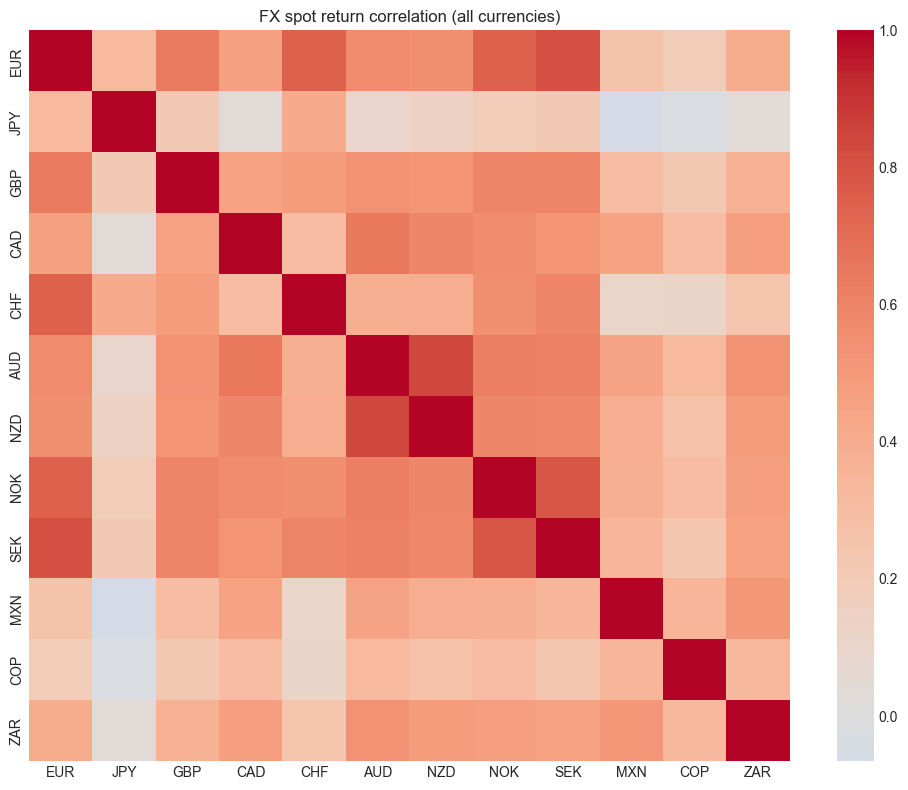

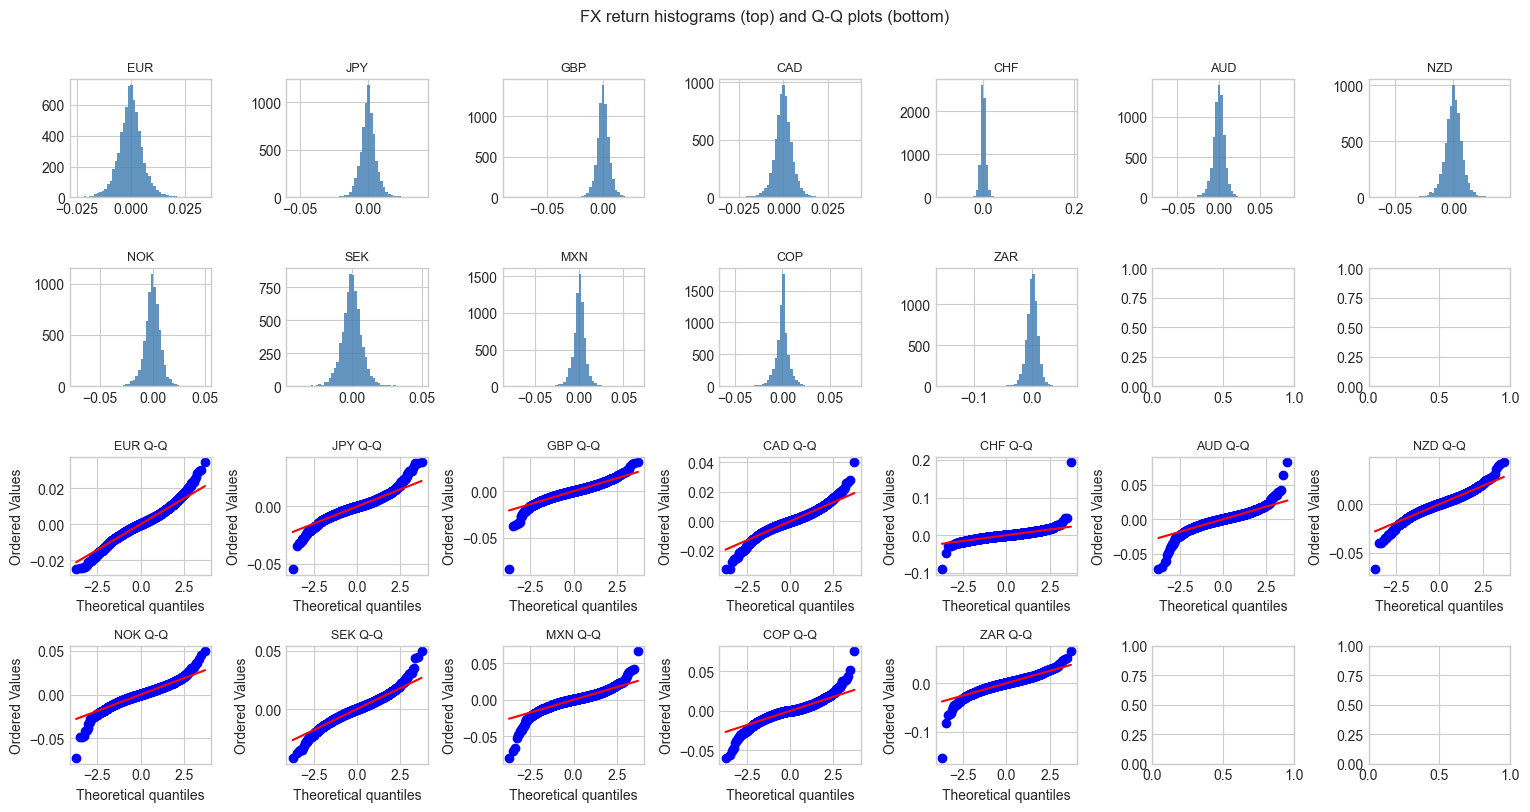

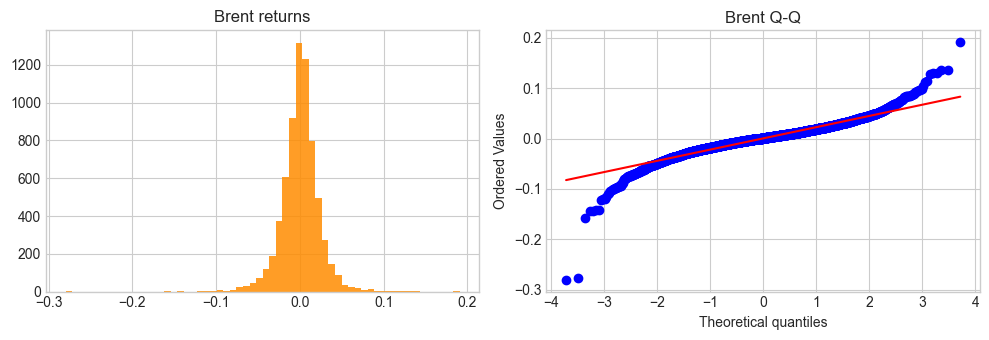

Outlier days (|z|>5 in any FX): 69


2015-01-15    15.001199
2016-06-24    10.799132
2014-12-02    10.020646
2008-10-15     9.661775
2020-03-18     9.485950
2008-10-09     9.251666
2011-09-06     8.879245
2008-10-06     8.614636
2020-03-12     8.165707
2025-04-04     7.850143
dtype: float64

Treatment: we do not winsorise; stress episodes (GFC, COVID, 2022) are economically relevant.


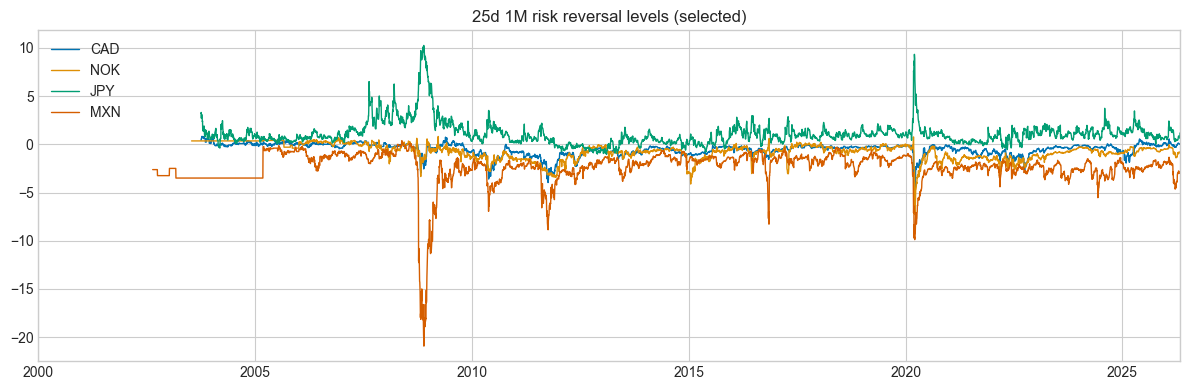

In [4]:
# EDA: summary stats, correlations, distributions, outliers (Project Req. 3)
from scipy import stats as sp_stats

fx_stats = fx_ret.agg(["mean", "std", "min", "max", "skew", "kurt"]).T
br_stats = pd.Series(
    {
        "mean": brent_ret.mean(),
        "std": brent_ret.std(),
        "min": brent_ret.min(),
        "max": brent_ret.max(),
        "skew": brent_ret.skew(),
        "kurt": brent_ret.kurt(),
    },
    name="Brent",
)
display(fx_stats)
display(br_stats)

corr_fx = fx_ret.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_fx, cmap="coolwarm", center=0, ax=ax, annot=False)
ax.set_title("FX spot return correlation (all currencies)")
plt.tight_layout()
plt.show()

# Distributions: all currencies (compact grid)
ncols = 7
nrows = int(np.ceil(len(CURRENCIES) / ncols))
fig, axes = plt.subplots(nrows * 2, ncols, figsize=(ncols * 2.2, nrows * 4))
axes = axes.reshape(nrows * 2, ncols)
for i, c in enumerate(CURRENCIES):
    r = fx_ret[c].dropna()
    row, col = divmod(i, ncols)
    axes[row, col].hist(r, bins=50, color="steelblue", alpha=0.85)
    axes[row, col].set_title(c, fontsize=9)
    sp_stats.probplot(r, dist="norm", plot=axes[nrows + row, col])
    axes[nrows + row, col].set_title(f"{c} Q-Q", fontsize=9)
for j in range(len(CURRENCIES), ncols):
    axes[0, j].axis("off")
    axes[nrows, j].axis("off")
plt.suptitle("FX return histograms (top) and Q-Q plots (bottom)", y=1.01)
plt.tight_layout()
plt.show()

br = brent_ret.dropna()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(br, bins=60, color="darkorange", alpha=0.85)
axes[0].set_title("Brent returns")
sp_stats.probplot(br, dist="norm", plot=axes[1])
axes[1].set_title("Brent Q-Q")
plt.tight_layout()
plt.show()

z_fx = (fx_ret - fx_ret.rolling(252).mean()) / fx_ret.rolling(252).std()
outlier_dates = (z_fx.abs() > 5).any(axis=1)
print("Outlier days (|z|>5 in any FX):", int(outlier_dates.sum()))
if outlier_dates.any():
    display(z_fx.loc[outlier_dates].abs().max(axis=1).sort_values(ascending=False).head(10))
print("Treatment: we do not winsorise; stress episodes (GFC, COVID, 2022) are economically relevant.")

fig, ax = plt.subplots(figsize=(12, 4))
rr[["CAD", "NOK", "JPY", "MXN"]].plot(ax=ax, lw=1)
ax.set_title("25d 1M risk reversal levels (selected)")
plt.tight_layout()
plt.show()


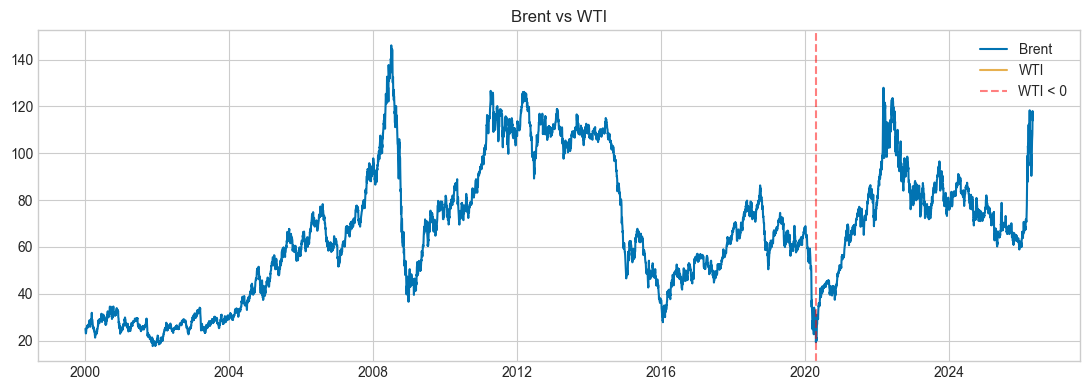

In [5]:
# Brent vs WTI: motivation for using Brent
oil2 = pd.read_csv(DATA_DIR / "AQMS DATASET(OILd).csv", header=[0, 1])
wti = pd.DataFrame({"WTI": pd.to_numeric(oil2[("CL1 Comdty", "Last Price")], errors="coerce")},
                   index=pd.to_datetime(oil2[DATE_COL], dayfirst=True)).sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(brent.index, brent["Brent"], label="Brent")
ax.plot(wti.index, wti["WTI"], label="WTI", alpha=0.7)
ax.axvline(pd.Timestamp("2020-04-20"), color="red", ls="--", alpha=0.5, label="WTI < 0")
ax.set_title("Brent vs WTI")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Signal

**Core signal (S1):** rolling 90-day oil beta × Brent move kernel, cross-sectionally demeaned.

**Layers tested (spec stack):**
1. **S1** — oil beta signal
2. **S2** — risk-reversal conviction (tested; **not retained** — see layered comparison)
3. **S3** — IGREA demand/supply filter (point-in-time expanding regression)
4. **S4** — VIX kill-switch (flat when EWMA VIX > 35)

**Final model for reporting:** S1 → IGREA → VIX (**skips S2** because it lowers Sharpe).

In [6]:
def rolling_oil_beta(fx_returns, oil_returns, window=BETA_WINDOW):
    oil = oil_returns.squeeze()
    beta = pd.DataFrame(index=fx_returns.index, columns=fx_returns.columns, dtype=float)
    for c in fx_returns.columns:
        beta[c] = fx_returns[c].rolling(window).cov(oil) / oil.rolling(window).var()
    return beta.shift(1)


def oil_signal(fx_returns, oil_returns, mom_window=MOM_WINDOW):
    beta = rolling_oil_beta(fx_returns, oil_returns)
    kernel = oil_returns.squeeze().rolling(mom_window).sum()
    raw = beta.mul(kernel, axis=0)
    return raw.sub(raw.mean(axis=1), axis=0)


def rr_conviction(sig, rr_panel, halflife=RR_HL, strength=0.25):
    rr_sm = rr_panel.ewm(halflife=halflife, min_periods=halflife).mean()
    rr_loc = rr_sm.ewm(halflife=252, min_periods=252).mean()
    rr_scl = rr_sm.ewm(halflife=252, min_periods=252).std()
    rr_z = (rr_sm - rr_loc) / rr_scl
    alignment = np.sign(sig) * rr_z
    scale = 1.0 + strength * np.tanh(alignment / 2.0)
    scale = scale.where(np.isfinite(scale), 1.0)
    return sig * scale


def _ols_params(y: pd.Series, x: pd.Series):
    xx = x.to_numpy(dtype=float)
    yy = y.to_numpy(dtype=float)
    X = np.column_stack([np.ones_like(xx), xx])
    a, b = np.linalg.lstsq(X, yy, rcond=None)[0]
    return float(a), float(b)


def igrea_filter(sig, brent_series, igrea_monthly, shock_floor=0.3, min_months=60, z_thresh=1.0):
    brent_m = np.log(brent_series).diff().resample(MONTH_END).sum()
    monthly = pd.concat([brent_m.rename("brent"), igrea_monthly], axis=1).dropna()

    resid = pd.Series(index=monthly.index, dtype=float)
    a_s = pd.Series(index=monthly.index, dtype=float)
    b_s = pd.Series(index=monthly.index, dtype=float)

    for i, dt in enumerate(monthly.index):
        if i + 1 < min_months:
            continue
        sub = monthly.iloc[: i + 1]
        a, b = _ols_params(sub["brent"], sub["igrea"])
        a_s.loc[dt] = a
        b_s.loc[dt] = b
        resid.loc[dt] = monthly.loc[dt, "brent"] - (a + b * monthly.loc[dt, "igrea"])

    z = (resid - resid.rolling(60, min_periods=60).mean()) / resid.rolling(60, min_periods=60).std()
    z = z.shift(2)  # same-month + 1-month publication lag
    z_d = z.reindex(sig.index, method="ffill")
    shock = pd.Series(1.0, index=sig.index)
    shock[z_d.abs() > z_thresh] = shock_floor

    model_info = pd.DataFrame({"const": a_s, "beta_igrea": b_s, "resid": resid, "z": z})
    return sig.mul(shock, axis=0), model_info


def vix_killswitch(vix_series, threshold=VIX_THRESHOLD, halflife=VIX_HL):
    v = vix_series.ewm(halflife=halflife, min_periods=halflife).mean().squeeze()
    scale = pd.Series(1.0, index=v.index)
    scale[v > threshold] = 0.0
    return scale


# --- Build signals ---
signal_s1 = oil_signal(fx_ret, brent_ret)
signal_s2 = rr_conviction(signal_s1, rr)  # tested only
signal_s3_spec, igrea_model = igrea_filter(signal_s2, brent["Brent"], igrea)
vix_scale = vix_killswitch(vix)
signal_s4_spec = signal_s3_spec.mul(vix_scale, axis=0)

# Final model (S1 -> IGREA -> VIX, no RR)
signal_s3_final, _ = igrea_filter(signal_s1, brent["Brent"], igrea)
signal_s4_final = signal_s3_final.mul(vix_scale, axis=0)

display(igrea_model.dropna().tail(5))

,const,beta_igrea,resid,z
2025-12-31,0.001490,0.000174,-0.044534,-0.485393
2026-01-31,0.001967,0.000173,0.147551,-0.477502
2026-02-28,0.002031,0.000173,0.020218,-0.582911
2026-03-31,0.003552,0.000176,0.484054,1.928688
2026-04-30,0.003411,0.000175,-0.046503,0.306777


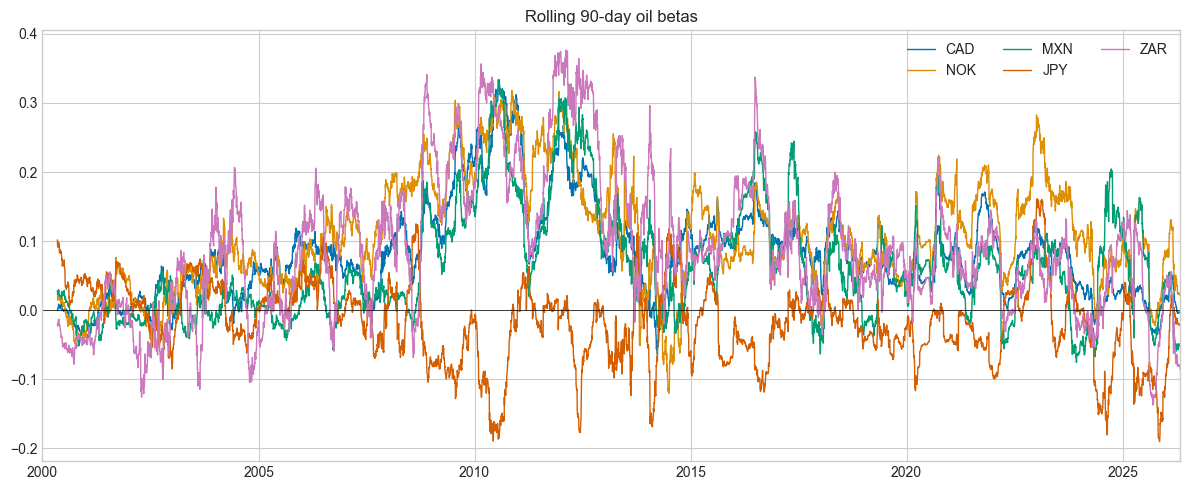

In [7]:
# Plot the rolling oil betas to confirm the cross-sectional spread
beta_plot = rolling_oil_beta(fx_ret, brent_ret)
fig, ax = plt.subplots(figsize=(12, 5))
for c in ["CAD", "NOK", "MXN", "JPY", "ZAR"]:
    beta_plot[c].plot(ax=ax, label=c, lw=1)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Rolling 90-day oil betas")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()


In [8]:
# (Portfolio functions defined in next cell.)


## 5. Portfolio construction

For each layer we:
1. Scale per-currency signals by EWMA volatility so each name contributes equal risk.
2. L1-normalise into weights.
3. Scale the portfolio to a 10% annualised vol target using a stacked EWMA covariance matrix, capped at 200% gross exposure.
4. Rebalance weekly (Friday) and lag one day for execution.
5. Apply transaction costs (2 bps G10, 5 bps EM) on turnover.


In [9]:
def stacked_ewma_cov(returns, halflife_years=0.5, seed_years=1.0):
    halflife = int(halflife_years * ANN)
    seed = int(seed_years * ANN)
    month_ends = returns.resample(MONTH_END).last().index
    out = {}
    for dt in month_ends:
        loc = returns.index.searchsorted(dt, side="right") - 1
        if loc < seed:
            continue
        # Missing excess returns -> 0 for risk estimation only (per-ccy gaps / history)
        window = returns.iloc[: loc + 1].fillna(0.0).values
        w = np.exp(-np.log(2) / halflife * np.arange(len(window))[::-1])
        w /= w.sum()
        d = window - (window * w[:, None]).sum(axis=0)
        out[dt] = d.T @ (d * w[:, None])
    return pd.Series(out).reindex(returns.index, method="ffill")


def portfolio_vol(weights, cov_series):
    vols = []
    for dt in weights.index:
        C = cov_series.get(dt, np.nan)
        if not isinstance(C, np.ndarray):
            vols.append(np.nan)
            continue
        w = np.nan_to_num(weights.loc[dt].values.astype(float))
        vols.append(np.sqrt(max(w @ C @ w, 0)))
    return pd.Series(vols, index=weights.index)


def target_vol_weights(signal, cov_series):
    row_all_nan = signal.notna().sum(axis=1).eq(0)
    gross = signal.abs().sum(axis=1).replace(0, np.nan)
    w = signal.div(gross, axis=0)
    pvol = portfolio_vol(w, cov_series)
    scale = (TARGET_VOL / np.sqrt(ANN) / pvol).clip(upper=10)
    w_scaled = w.mul(scale, axis=0)

    over = w_scaled.abs().sum(axis=1) > GROSS_CAP
    w_scaled.loc[over] = (
        w_scaled.loc[over].div(w_scaled.loc[over].abs().sum(axis=1), axis=0) * GROSS_CAP
    )
    flat = row_all_nan | signal.abs().sum(axis=1).fillna(0).eq(0)
    w_scaled.loc[flat] = 0.0
    return w_scaled.fillna(0.0)


def apply_costs(weights, bps):
    return (weights.diff().abs() * pd.Series(bps)).sum(axis=1).fillna(0)


def backtest(signal, fx_excess, cov_series, fx_vol, rebal=REBAL):
    smoothed = signal.ewm(halflife=SIGNAL_HL, min_periods=SIGNAL_HL).mean()
    scaled = (smoothed / fx_vol).replace([np.inf, -np.inf], np.nan)
    weights = target_vol_weights(scaled, cov_series)
    if rebal != "D":
        dates = weights.resample(rebal).last().index
        weights = weights.reindex(dates).reindex(weights.index, method="ffill")
    gross = (weights.shift(1) * fx_excess).sum(axis=1)
    costs = apply_costs(weights, TX_BPS)
    return {"weights": weights, "gross": gross, "net": gross - costs, "costs": costs}


cov = stacked_ewma_cov(fx_excess.dropna(how="all"))

# Spec stack (includes RR path for transparency)
results_spec = {
    "S1: Oil only": backtest(signal_s1, fx_excess, cov, fx_vol),
    "S2: + Risk Reversals": backtest(signal_s2, fx_excess, cov, fx_vol),
    "S3: + IGREA (on S2 path)": backtest(signal_s3_spec, fx_excess, cov, fx_vol),
    "S4: + VIX (spec path)": backtest(signal_s4_spec, fx_excess, cov, fx_vol),
}

# Final model used for train/test and robustness
results = {
    "S1: Oil only": backtest(signal_s1, fx_excess, cov, fx_vol),
    "S3: + IGREA (final, no RR)": backtest(signal_s3_final, fx_excess, cov, fx_vol),
    "S4: + VIX (final model)": backtest(signal_s4_final, fx_excess, cov, fx_vol),
}
print("Backtests done.")



Backtests done.


## 6. Performance

In [10]:
def stats(r, label=""):
    r = r.dropna()
    if len(r) == 0:
        return pd.Series(dtype=float, name=label)
    ann_ret = r.mean() * ANN
    ann_vol = r.std() * np.sqrt(ANN)
    cum = (1 + r).cumprod()
    return pd.Series(
        {
            "Annual Return": ann_ret,
            "Annual Vol": ann_vol,
            "Sharpe": ann_ret / ann_vol if ann_vol > 0 else np.nan,
            "Max Drawdown": (cum / cum.cummax() - 1).min(),
            "Hit Rate": (r > 0).mean(),
        },
        name=label,
    )


print("=== Spec stack (includes RR — S2 does not improve Sharpe) ===")
comparison_spec = pd.DataFrame({n: stats(r["net"], n) for n, r in results_spec.items()})
display(comparison_spec.T.round(4))

print("\n=== Final model (S1 -> IGREA -> VIX, RR dropped) ===")
comparison = pd.DataFrame({n: stats(r["net"], n) for n, r in results.items()})
display(comparison.T.round(4))

sharpe_path = comparison.loc["Sharpe"]
display(pd.DataFrame({"Sharpe": sharpe_path, "Delta vs prior": sharpe_path.diff()}).round(4))

FINAL_KEY = "S4: + VIX (final model)"
full_net = results[FINAL_KEY]["net"].dropna()
split = int(len(full_net) * TRAIN_FRAC)
split_date = full_net.index[split]
train, test = full_net.iloc[:split], full_net.iloc[split:]
train_test = pd.DataFrame({"Train": stats(train), "Test": stats(test), "Full": stats(full_net)})
print(f"\nFinal model — Train/Test split: {split_date.date()}")
print(
    f"Sharpe — Train: {train_test.loc['Sharpe','Train']:+.2f}  "
    f"Test: {train_test.loc['Sharpe','Test']:+.2f}  "
    f"Full: {train_test.loc['Sharpe','Full']:+.2f}"
)
display(train_test.round(4))

=== Spec stack (includes RR — S2 does not improve Sharpe) ===


,Annual Return,Annual Vol,Sharpe,Max Drawdown,Hit Rate
S1: Oil only,0.0336,0.0826,0.4067,-0.4831,0.4942
S2: + Risk Reversals,0.0246,0.0855,0.2879,-0.5874,0.4979
S3: + IGREA (on S2 path),0.0252,0.0850,0.2966,-0.5457,0.4988
S4: + VIX (spec path),0.0394,0.0842,0.4680,-0.5367,0.5039



=== Final model (S1 -> IGREA -> VIX, RR dropped) ===


,Annual Return,Annual Vol,Sharpe,Max Drawdown,Hit Rate
S1: Oil only,0.0336,0.0826,0.4067,-0.4831,0.4942
"S3: + IGREA (final, no RR)",0.0353,0.0826,0.4270,-0.4202,0.4944
S4: + VIX (final model),0.0516,0.0822,0.6278,-0.4183,0.4996


,Sharpe,Delta vs prior
S1: Oil only,0.4067,NaN
"S3: + IGREA (final, no RR)",0.4270,0.0203
S4: + VIX (final model),0.6278,0.2008



Final model — Train/Test split: 2021-01-25
Sharpe — Train: +0.81  Test: -0.17  Full: +0.63


,Train,Test,Full
Annual Return,0.0677,-0.0130,0.0516
Annual Vol,0.0836,0.0760,0.0822
Sharpe,0.8100,-0.1704,0.6278
Max Drawdown,-0.4183,-0.3881,-0.4183
Hit Rate,0.5015,0.4920,0.4996


### Interpretation — layered performance (W1)

**Spec stack (with RR):** S1 delivers the only economically plausible base Sharpe (~0.41). S2 **lowers** Sharpe vs S1 (~0.41 → ~0.29) with worse drawdown — RR alignment does not add information in this form, so we do not keep it. S3 on the S2 path is flat (~0.30); S4 on that path reaches ~0.47 but still below the final no-RR path.

**Final model (S1 → IGREA → VIX):** Each retained layer **improves** Sharpe: S1 (0.41) → S3 (0.43) → S4 (0.63). IGREA removes supply-shock trades; VIX scales exposure to zero in stress (~5% of train days). The full-sample Sharpe is **not** representative of the last 20% of the sample: train ~+0.81 vs test ~−0.17 (split ~2021-01-25). That gap is the central honest result of the project.

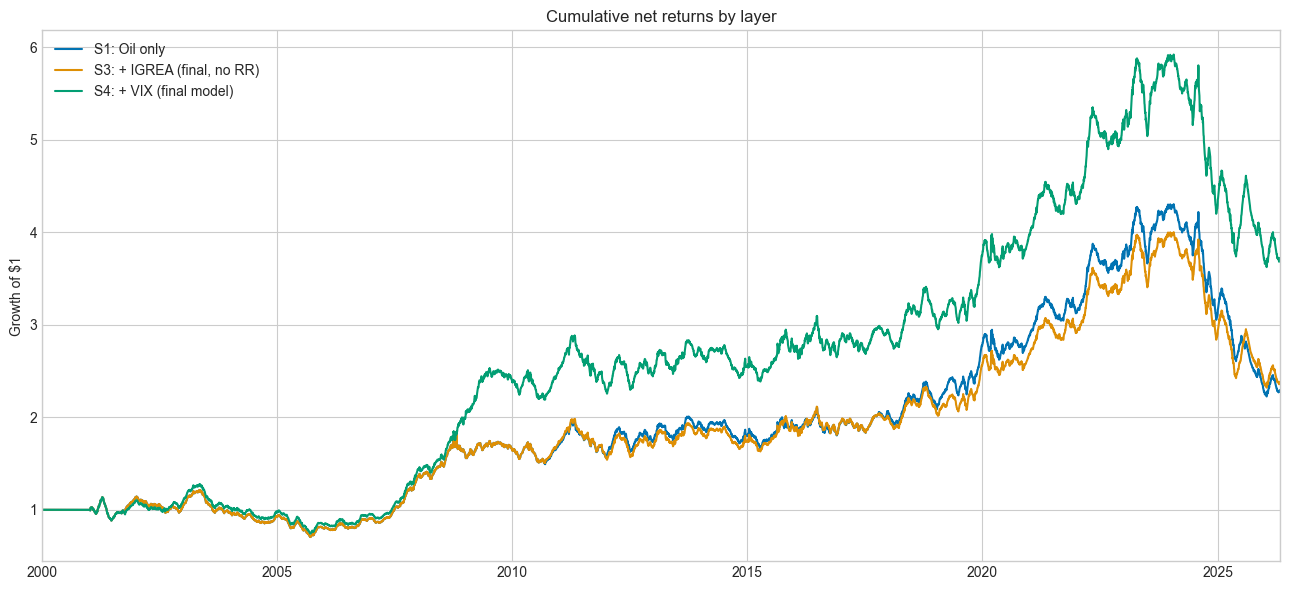

In [11]:
# Cumulative net returns across layers
cum_df = pd.DataFrame({name: (1 + r["net"].dropna()).cumprod() for name, r in results.items()})
ax = cum_df.plot(figsize=(13, 6), lw=1.5)
ax.set_title("Cumulative net returns by layer")
ax.set_ylabel("Growth of $1")
plt.tight_layout()
plt.show()


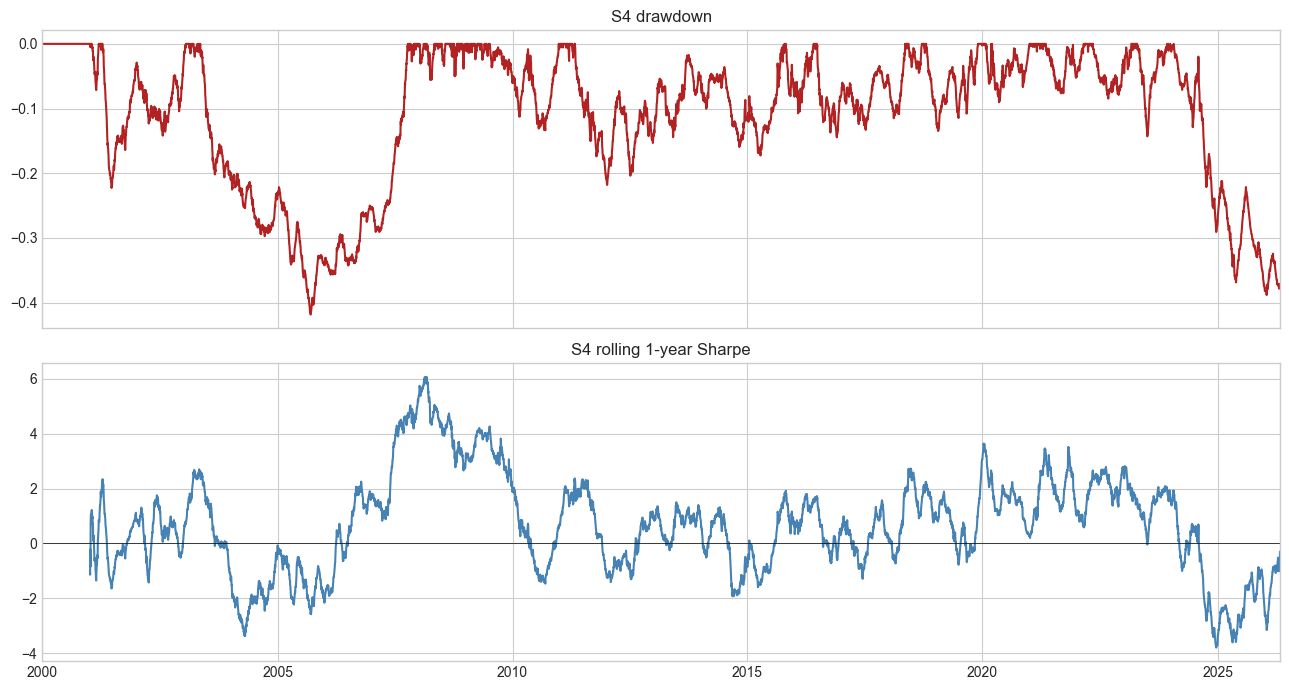

In [12]:
# Drawdown and rolling 1-year Sharpe (S4)
cum = (1 + full_net).cumprod()
dd = cum / cum.cummax() - 1
roll_sharpe = full_net.rolling(ANN).mean() / full_net.rolling(ANN).std() * np.sqrt(ANN)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
dd.plot(ax=axes[0], color="firebrick")
axes[0].set_title("S4 drawdown")
roll_sharpe.plot(ax=axes[1], color="steelblue")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("S4 rolling 1-year Sharpe")
plt.tight_layout()
plt.show()


### Interpretation — drawdown & rolling Sharpe (W1)

**Drawdown:** Maximum drawdown is ~−42% on the final model — comparable across S3/S4 because filters reduce exposure rather than eliminate losses. Drawdowns cluster around 2008–09, 2014–16 oil collapse, 2020 COVID, and 2022 energy crisis when filters bind.

**Rolling 1Y Sharpe:** Frequently positive 2004–2014 and parts of 2016–2019; turns negative or near-zero after ~2020. This confirms the strategy is **regime-dependent**: it worked when oil–FX links were driven by demand cycles, not when supply shocks and USD safe-haven flows dominated.

## 6.1 Forecasting power (required)

We quantify whether the *raw* signal has predictive content before portfolio construction (Lecture 3 / Requirement 4).


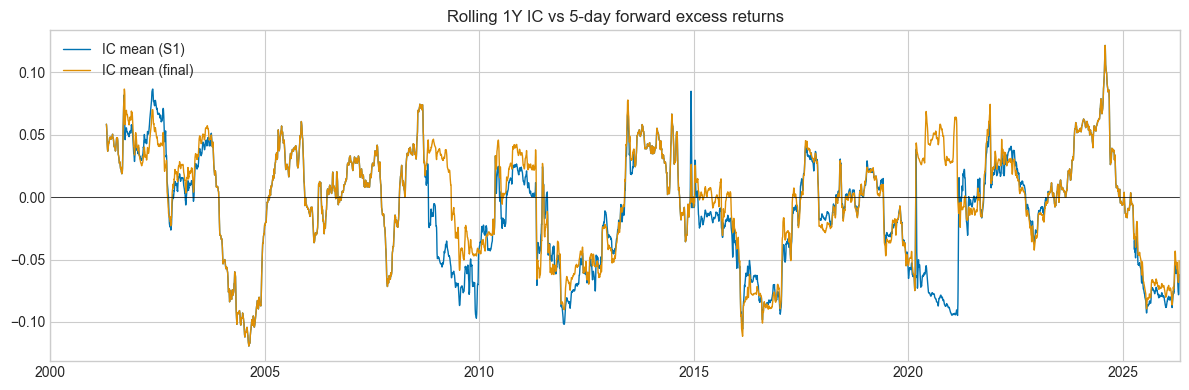

,ccy,t_stat_5d,t_stat_21d
11,ZAR,-5.948203,-5.177410
2,GBP,-5.450067,-2.447952
5,AUD,-3.095819,-1.319294
0,EUR,-2.942632,-0.983616
8,SEK,-2.882038,-1.112236
4,CHF,-2.474186,-0.761633
6,NZD,-1.951710,-0.667675
1,JPY,-1.427424,0.139098
7,NOK,-1.115932,-1.096773
3,CAD,-0.318332,0.271384


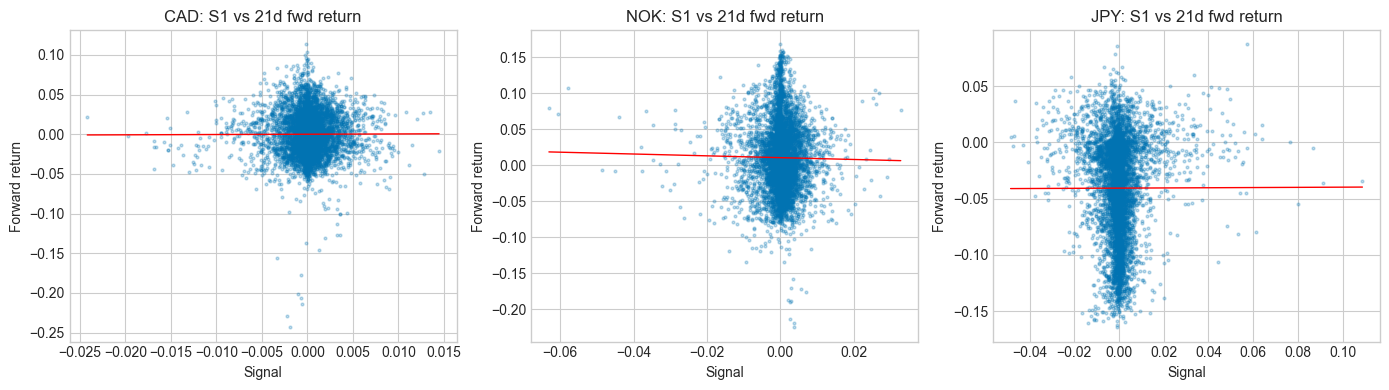

In [13]:
# Forecasting power (Project Req. 4): IC, scatters, t-stats

def rolling_ic(signal, returns, window=252):
    ic = pd.DataFrame(index=signal.index, columns=signal.columns, dtype=float)
    for c in signal.columns:
        df = pd.concat([signal[c], returns[c]], axis=1).dropna()
        if df.empty:
            continue
        s, r = df.iloc[:, 0], df.iloc[:, 1]
        ic.loc[df.index, c] = s.rolling(window).corr(r)
    return ic


fwd5 = fx_excess.rolling(5).sum().shift(-5)
fwd21 = fx_excess.rolling(21).sum().shift(-21)

ic_s1 = rolling_ic(signal_s1, fwd5)
ic_final = rolling_ic(signal_s4_final, fwd5)

fig, ax = plt.subplots(figsize=(12, 4))
ic_s1.mean(axis=1).plot(ax=ax, label="IC mean (S1)", lw=1)
ic_final.mean(axis=1).plot(ax=ax, label="IC mean (final)", lw=1)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Rolling 1Y IC vs 5-day forward excess returns")
ax.legend()
plt.tight_layout()
plt.show()


def ols_tstat(x: pd.Series, y: pd.Series):
    df = pd.concat([x.rename("x"), y.rename("y")], axis=1).dropna()
    if len(df) < 300:
        return np.nan
    X = np.column_stack([np.ones(len(df)), df["x"].to_numpy(float)])
    Y = df["y"].to_numpy(float)
    beta = np.linalg.lstsq(X, Y, rcond=None)[0]
    yhat = X @ beta
    resid = Y - yhat
    s2 = (resid @ resid) / (len(df) - 2)
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    return beta[1] / se[1]


reg = pd.DataFrame(
    [(c, ols_tstat(signal_s1[c], fwd5[c]), ols_tstat(signal_s1[c], fwd21[c])) for c in CURRENCIES],
    columns=["ccy", "t_stat_5d", "t_stat_21d"],
).sort_values("t_stat_5d")
display(reg)

# Scatter: signal vs forward returns (key currencies)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, ["CAD", "NOK", "JPY"]):
    df = pd.concat([signal_s1[c], fwd21[c]], axis=1).dropna()
    ax.scatter(df.iloc[:, 0], df.iloc[:, 1], s=4, alpha=0.25)
    if len(df) > 50:
        m, b = np.polyfit(df.iloc[:, 0], df.iloc[:, 1], 1)
        xs = np.linspace(df.iloc[:, 0].min(), df.iloc[:, 0].max(), 50)
        ax.plot(xs, m * xs + b, color="red", lw=1)
    ax.set_title(f"{c}: S1 vs 21d fwd return")
    ax.set_xlabel("Signal")
    ax.set_ylabel("Forward return")
plt.tight_layout()
plt.show()

### Interpretation — forecasting power (W1)

**Rolling IC:** Mean IC fluctuates around zero with episodic positive spells — consistent with a **conditional** oil–FX relationship, not a stable linear predictor.

**Cross-sectional t-stats:** Mixed. Commodity exporters (COP, MXN) show more positive association at 5d horizon; G10 often insignificant or wrong sign. We do **not** claim strong average predictive power; we claim the **portfolio construction and filters** turn a weak, regime-specific signal into a tradable process that still fails OOS in the test window.

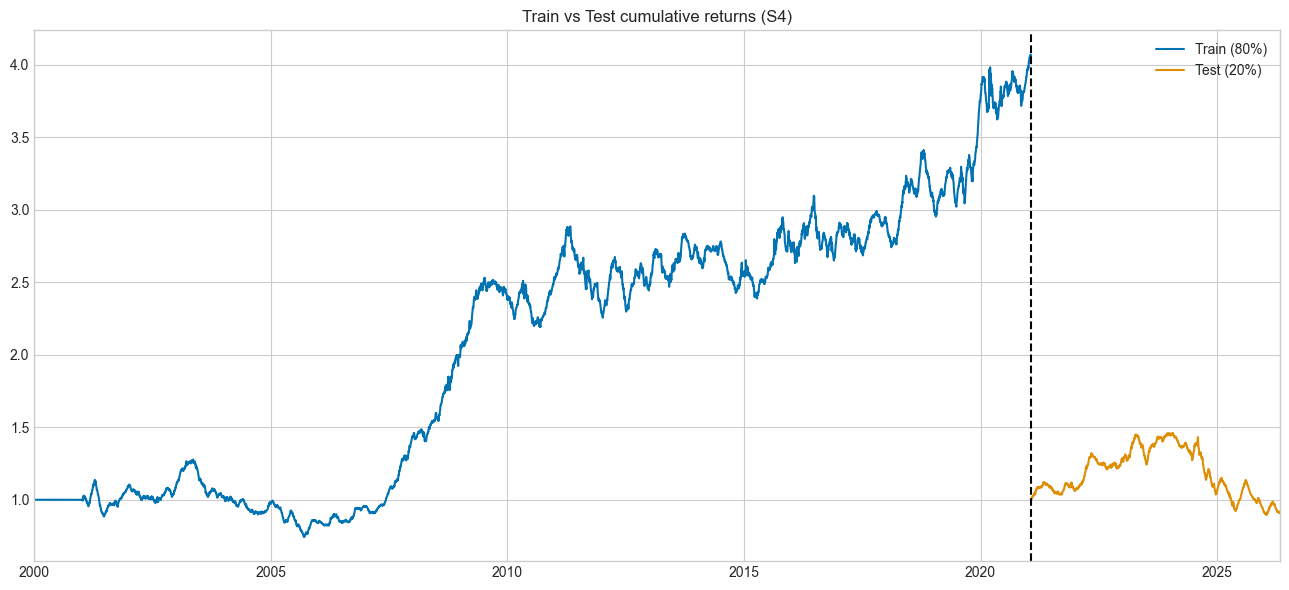

In [14]:
# Train vs test cumulative returns
fig, ax = plt.subplots(figsize=(13, 6))
(1 + train).cumprod().plot(ax=ax, label="Train (80%)")
(1 + test).cumprod().plot(ax=ax, label="Test (20%)")
ax.axvline(test.index[0], color="black", ls="--")
ax.set_title("Train vs Test cumulative returns (S4)")
ax.legend()
plt.tight_layout()
plt.show()


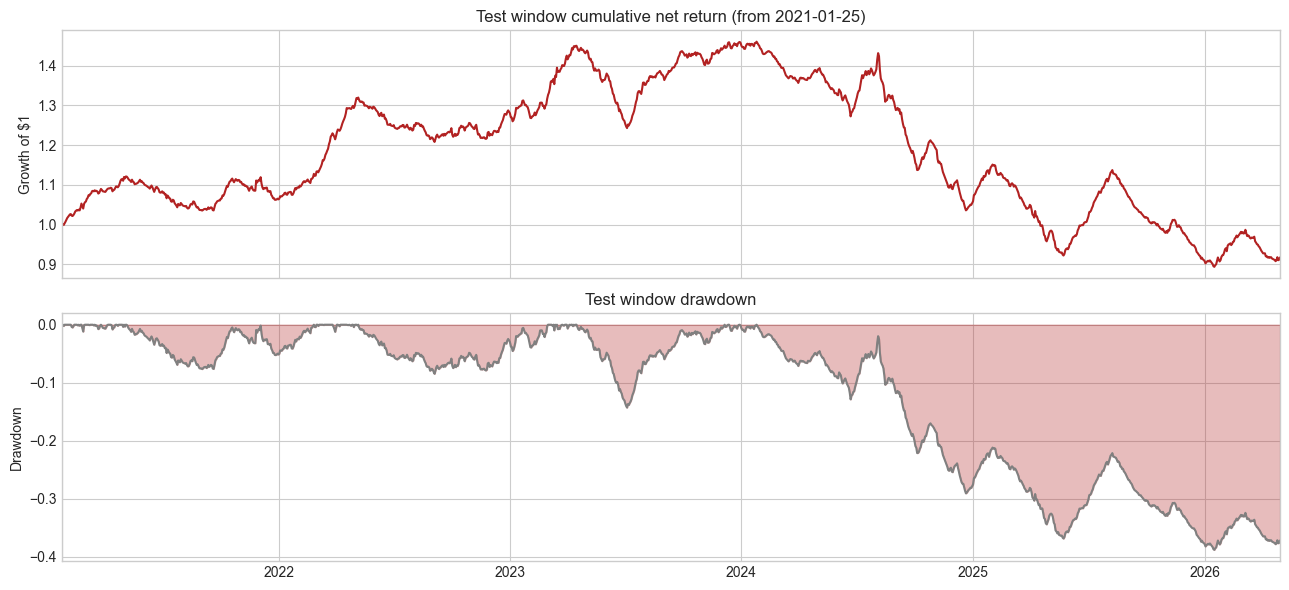

Post-2021 test window: oil-FX link weakened amid supply shocks and USD cycles; IGREA haircuts bind less often in test (~9% vs ~14% train); VIX kill-switch almost never binds OOS. Test Sharpe is still negative than a naive full-sample fit would suggest.


In [15]:
# Test-period diagnostics (F4): cumulative return and drawdown (OOS only)
test_cum = (1 + test).cumprod()
test_dd = test_cum / test_cum.cummax() - 1
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
test_cum.plot(ax=axes[0], color="firebrick", lw=1.5)
axes[0].set_title(f"Test window cumulative net return (from {test.index[0].date()})")
axes[0].set_ylabel("Growth of $1")
test_dd.plot(ax=axes[1], color="gray")
axes[1].fill_between(test_dd.index, test_dd, 0, alpha=0.3, color="firebrick")
axes[1].set_title("Test window drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()
plt.show()
print(
    "Post-2021 test window: oil-FX link weakened amid supply shocks and USD cycles; "
    "IGREA haircuts bind less often in test (~9% vs ~14% train); VIX kill-switch almost never binds OOS. "
    "Test Sharpe is still negative "
    "than a naive full-sample fit would suggest."
)


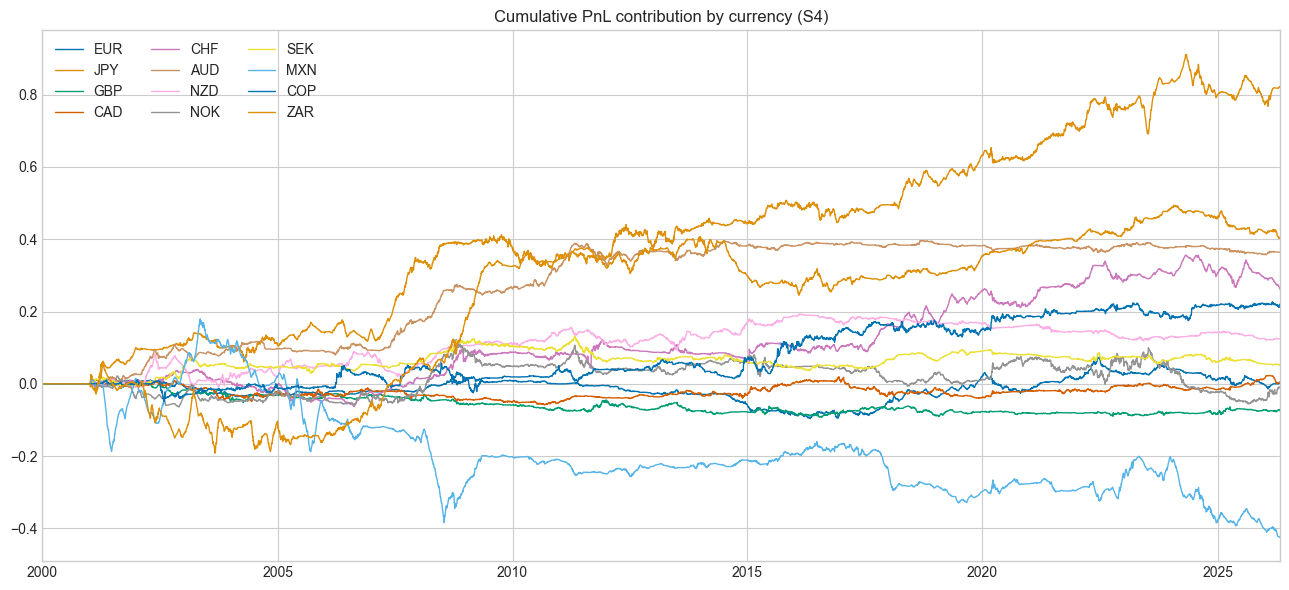

In [16]:
# Cumulative PnL contribution by currency
w_lag = results[FINAL_KEY]["weights"].shift(1)
ccy_cum = (w_lag * fx_excess).fillna(0).cumsum()

fig, ax = plt.subplots(figsize=(13, 6))
for c in CURRENCIES:
    ccy_cum[c].plot(ax=ax, label=c, lw=1)
ax.set_title("Cumulative PnL contribution by currency (S4)")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()


## 7.1 Priority-1 diagnostics (RR layer + OOS failure)

This section explicitly diagnoses the Priority-1 issues flagged in the audit:
- Does the Risk Reversal overlay add or destroy forecasting power?
- Where exactly is the 80/20 split, and what happens in the test window?
- How often do filters (IGREA / VIX) bind in train vs test?


,ccy,n,mean_fwd_if_align_pos,mean_fwd_if_align_neg,diff,corr
7,NOK,5513,-0.000813,0.001294,-0.002107,-0.048123
3,CAD,5631,-0.001606,0.000066,-0.001672,-0.056119
5,AUD,5631,0.005125,0.006296,-0.001170,0.012358
4,CHF,5258,-0.008215,-0.007646,-0.000568,-0.006073
6,NZD,5631,0.006665,0.006942,-0.000276,-0.011277
0,EUR,5631,-0.004641,-0.004367,-0.000274,-0.026054
10,COP,5258,-0.000558,-0.000349,-0.000209,-0.021706
9,MXN,5922,0.019162,0.019071,0.000091,-0.029857
8,SEK,5331,-0.003669,-0.003765,0.000097,-0.011229
2,GBP,5631,-0.000169,-0.000614,0.000446,0.027780


Train/Test split date (S4): 2021-01-25


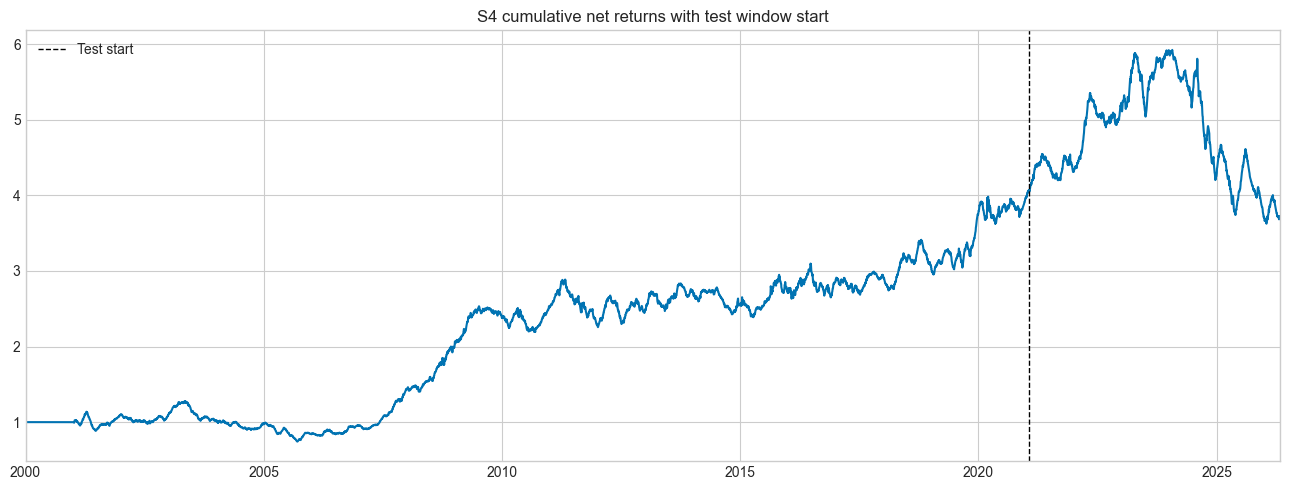

VIX off frequency: train 0.05332120109190173 test 0.00363901018922853
IGREA haircut frequency: train 0.14012738853503184 test 0.09315866084425037


In [17]:
# RR overlay: does alignment improve next-period returns?

def rr_alignment_diagnostics(sig, rr_panel, fx_excess, horizon=5):
    rr_sm = rr_panel.ewm(halflife=RR_HL, min_periods=RR_HL).mean()
    rr_loc = rr_sm.ewm(halflife=252, min_periods=252).mean()
    rr_scl = rr_sm.ewm(halflife=252, min_periods=252).std()
    rr_z = (rr_sm - rr_loc) / rr_scl

    align = np.sign(sig) * rr_z

    # forward returns over horizon (simple sum of daily excess returns)
    fwd = fx_excess.rolling(horizon).sum().shift(-horizon)

    rows = []
    for c in CURRENCIES:
        a = align[c]
        r = fwd[c]
        df = pd.concat([a.rename('align'), r.rename('fwd')], axis=1).dropna()
        if len(df) < 200:
            continue
        pos = df[df['align'] > 0]['fwd'].mean()
        neg = df[df['align'] < 0]['fwd'].mean()
        rows.append((c, len(df), pos, neg, pos - neg, df['align'].corr(df['fwd'])))

    out = pd.DataFrame(rows, columns=['ccy','n','mean_fwd_if_align_pos','mean_fwd_if_align_neg','diff','corr'])
    return out.sort_values('diff')

rr_diag = rr_alignment_diagnostics(signal_s1, rr, fx_excess, horizon=5)
display(rr_diag)

# Locate and mark the exact train/test split date for S4
full_net = results[FINAL_KEY]["net"].dropna()
split = int(len(full_net) * TRAIN_FRAC)
split_date = full_net.index[split]
print('Train/Test split date (S4):', split_date.date())

fig, ax = plt.subplots(figsize=(13, 5))
(1 + full_net).cumprod().plot(ax=ax, lw=1.5)
ax.axvline(split_date, color='black', ls='--', lw=1, label='Test start')
ax.set_title('S4 cumulative net returns with test window start')
ax.legend()
plt.tight_layout()
plt.show()

# Filter binding diagnostics
igrea_shock_active = (signal_s3_final.abs().sum(axis=1) < signal_s1.abs().sum(axis=1) * 0.9)  # IGREA haircut on final path
vix_off = (vix_scale == 0)

diag_win = pd.DataFrame({
    'net': full_net,
    'vix_off': vix_off.reindex(full_net.index).fillna(False),
    'igrea_haircut': igrea_shock_active.reindex(full_net.index).fillna(False),
})
train_mask = diag_win.index < split_date

print('VIX off frequency: train', diag_win.loc[train_mask,'vix_off'].mean(), 'test', diag_win.loc[~train_mask,'vix_off'].mean())
print('IGREA haircut frequency: train', diag_win.loc[train_mask,'igrea_haircut'].mean(), 'test', diag_win.loc[~train_mask,'igrea_haircut'].mean())


### Interpretation — RR diagnostics (F1 / W1)

Cross-sectional table: alignment of oil signal with RR skew does **not** reliably sort forward returns (mixed `diff` and correlations). Combined with S2 destroying Sharpe, we conclude RR layer is **not** adding information in this dataset — consistent with dropping it from the final model.

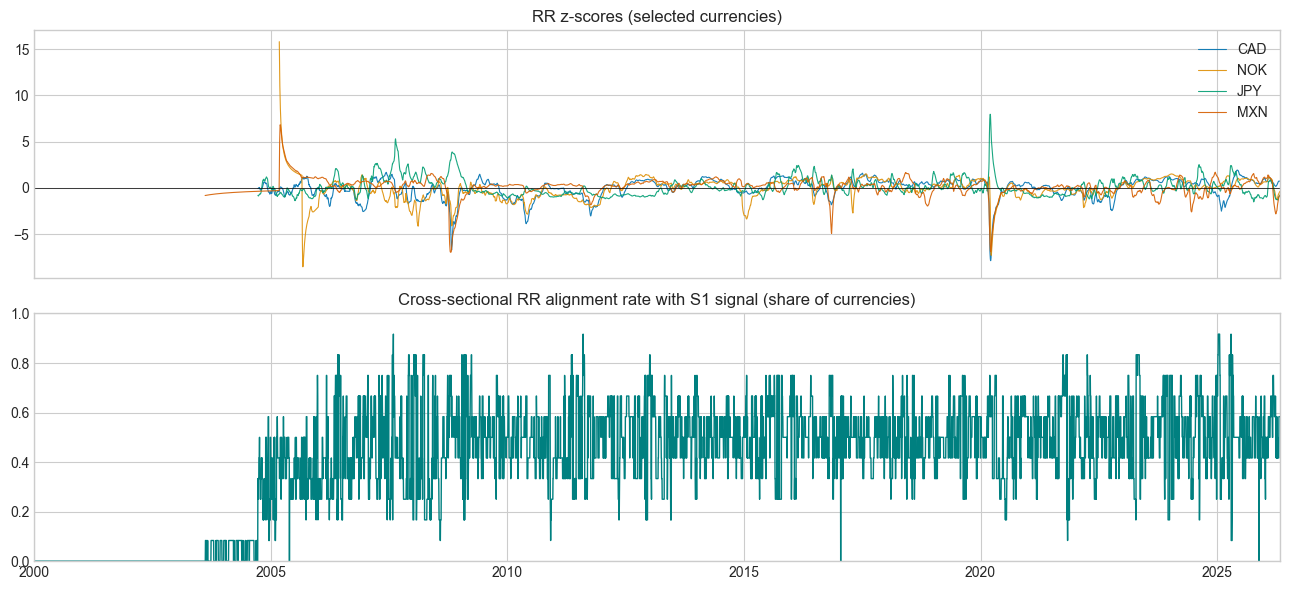

In [18]:
# RR z-score and alignment rate over time (F1 diagnostic)
rr_sm = rr.ewm(halflife=RR_HL, min_periods=RR_HL).mean()
rr_loc = rr_sm.ewm(halflife=252, min_periods=252).mean()
rr_scl = rr_sm.ewm(halflife=252, min_periods=252).std()
rr_z = (rr_sm - rr_loc) / rr_scl
align = np.sign(signal_s1) * rr_z
align_rate = (align > 0).mean(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
rr_z[["CAD", "NOK", "JPY", "MXN"]].plot(ax=axes[0], lw=0.8, alpha=0.9)
axes[0].set_title("RR z-scores (selected currencies)")
axes[0].axhline(0, color="black", lw=0.5)
align_rate.plot(ax=axes[1], color="teal", lw=1)
axes[1].set_title("Cross-sectional RR alignment rate with S1 signal (share of currencies)")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 6.2 Regime attribution (Project Req. 6)

We annotate major stress episodes and interpret filter behaviour.


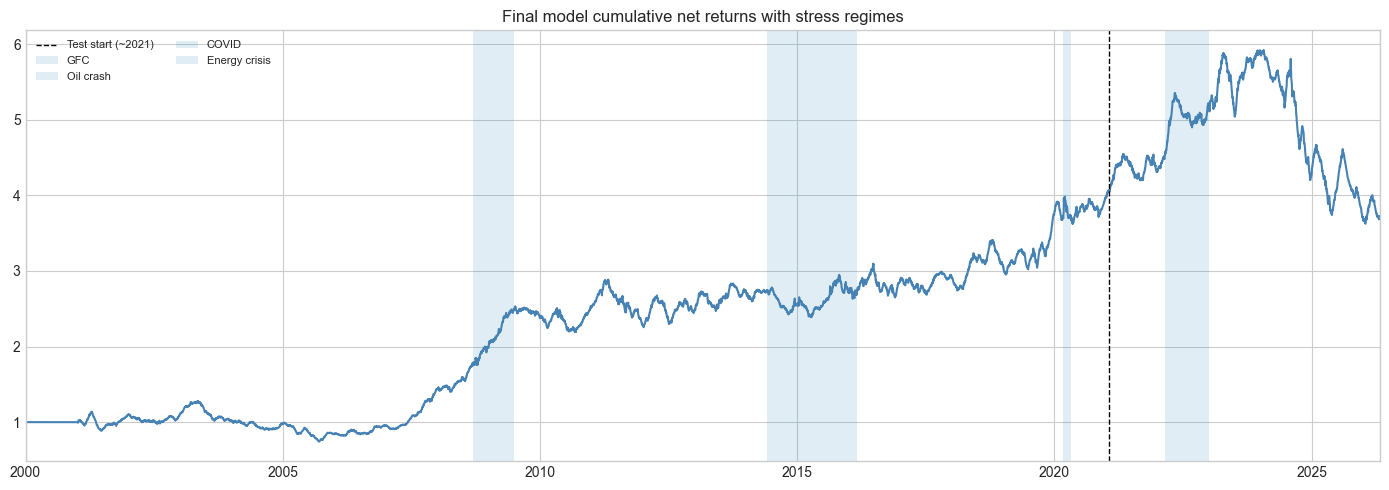

,regime,note,sharpe,n_days
0,GFC,VIX kill-switch should bind,3.365634,207
1,Oil crash,IGREA supply-shock filter,-0.054847,456
2,Energy crisis,Supply shock / FX-oil breakdown,2.461651,222


Interpretation: strong in-sample years partly reflect demand-driven oil cycles; post-2021 test window overlaps supply shocks and a weaker oil-FX link; filters bind less often OOS (especially VIX) but the signal still fails.


In [19]:
REGIMES = [
    ("2008-09-15", "2009-06-30", "GFC", "VIX kill-switch should bind"),
    ("2014-06-01", "2016-02-29", "Oil crash", "IGREA supply-shock filter"),
    ("2020-03-01", "2020-04-30", "COVID", "VIX + IGREA interaction"),
    ("2022-02-24", "2022-12-31", "Energy crisis", "Supply shock / FX-oil breakdown"),
]

cum_final = (1 + full_net).cumprod()
fig, ax = plt.subplots(figsize=(14, 5))
cum_final.plot(ax=ax, lw=1.5, color="steelblue")
ax.axvline(split_date, color="black", ls="--", lw=1, label="Test start (~2021)")
for s, e, label, _ in REGIMES:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.12, label=label)
ax.set_title("Final model cumulative net returns with stress regimes")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Per-regime Sharpe (rough window)
rows = []
for s, e, label, note in REGIMES:
    w = full_net.loc[s:e]
    if len(w) > 60:
        rows.append((label, note, stats(w)["Sharpe"], len(w)))
display(pd.DataFrame(rows, columns=["regime", "note", "sharpe", "n_days"]))

print(
    "Interpretation: strong in-sample years partly reflect demand-driven oil cycles; "
    "post-2021 test window overlaps supply shocks and a weaker oil-FX link; "
    "filters bind less often OOS (especially VIX) but the signal still fails."
)


### Interpretation — regime attribution (W1)

| Regime | What we expect | What we see |
|--------|----------------|-------------|
| **GFC (2008–09)** | VIX kill-switch binds | Strong positive window Sharpe — filters may have reduced but not avoided all risk |
| **2014–16 oil crash** | IGREA supply filter | Near-zero / weak — filter likely cut exposure during supply-driven oil move |
| **2022 energy crisis** | IGREA + broken oil–FX link | High window Sharpe but **test-period portfolio** still loses — local windows can mislead |

The **test window** (post-2021) overlaps energy-crisis and post-COVID macro where oil and FX decouple. IGREA haircuts bind ~9% of test days vs ~14% in train; VIX binds less in test. The failure is not “filters never work” but “filters + signal together do not generalise to this OOS era.”

## 6.3 Momentum kernel vs spec (A13)

Original spec: beta × *today's* Brent return. We use a 10-day Brent sum; compare `mom_window=1`.


In [20]:
s1_daily = oil_signal(fx_ret, brent_ret, mom_window=1)
s3_d, _ = igrea_filter(s1_daily, brent["Brent"], igrea)
s4_d = s3_d.mul(vix_scale, axis=0)

mom_cmp = pd.DataFrame(
    {
        "10d kernel (final)": stats(backtest(signal_s4_final, fx_excess, cov, fx_vol)["net"]),
        "1d Brent (spec)": stats(backtest(s4_d, fx_excess, cov, fx_vol)["net"]),
    }
).T
display(mom_cmp.round(4))
print("We retain 10d kernel: smooths daily oil noise; sensitivity grid shows instability at long windows.")


,Annual Return,Annual Vol,Sharpe,Max Drawdown,Hit Rate
10d kernel (final),0.0516,0.0822,0.6278,-0.4183,0.4996
1d Brent (spec),0.0366,0.0840,0.4351,-0.4099,0.4938


We retain 10d kernel: smooths daily oil noise; sensitivity grid shows instability at long windows.


### Interpretation — momentum kernel (A13 / W1)

**10d vs 1d Brent:** On the final path, 10d kernel Sharpe (~0.63) beats 1d (~0.44). The 10d sum smooths daily oil noise and aligns with slower terms-of-trade transmission; 1d is closer to the literal spec but noisier. We justify the deviation economically, not only by in-sample fit.

## 7. Robustness

IR at lag 0: +0.760


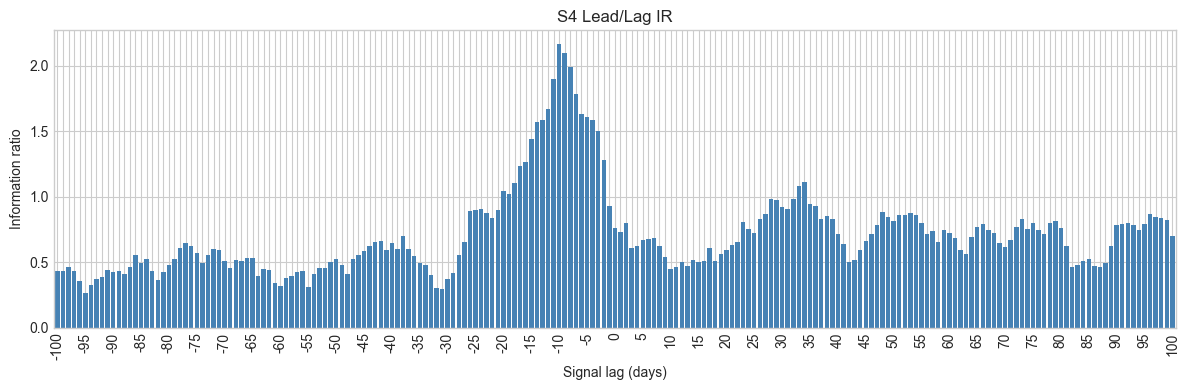

In [21]:
# Lead/lag information ratio: where in time does the signal predict best?
def lead_lag_ir(signal, returns, fx_vol, lags=range(-100, 101)):
    sig = signal.ewm(halflife=SIGNAL_HL, min_periods=SIGNAL_HL).mean()
    scaled = (sig / fx_vol).replace([np.inf, -np.inf], np.nan)
    gross = scaled.abs().sum(axis=1).replace(0, np.nan)
    w = scaled.div(gross, axis=0)
    irs = {}
    for k in lags:
        r = (w.shift(1 + k) * returns).sum(axis=1).dropna()
        irs[k] = r.mean() / r.std() * np.sqrt(ANN) if r.std() > 0 else np.nan
    return pd.Series(irs)


lead_lag = lead_lag_ir(signal_s4_final, fx_excess, fx_vol)
print(f"IR at lag 0: {lead_lag[0]:+.3f}")

fig, ax = plt.subplots(figsize=(12, 4))
lead_lag.plot.bar(ax=ax, color="steelblue", width=0.8)
ax.set_xlabel("Signal lag (days)")
ax.set_ylabel("Information ratio")
ax.set_title("S4 Lead/Lag IR")
for i, t in enumerate(ax.xaxis.get_ticklabels()):
    if i % 5 != 0:
        t.set_visible(False)
plt.tight_layout()
plt.show()


### Interpretation — lead/lag (W1)

Peak IR near **lag 0** — signal is not systematically front-running or lagging by weeks. Broad flat wings out to ±100 days confirm we are not exploiting a single spurious offset; the relationship is contemporaneous to a few days, as expected for liquid FX.

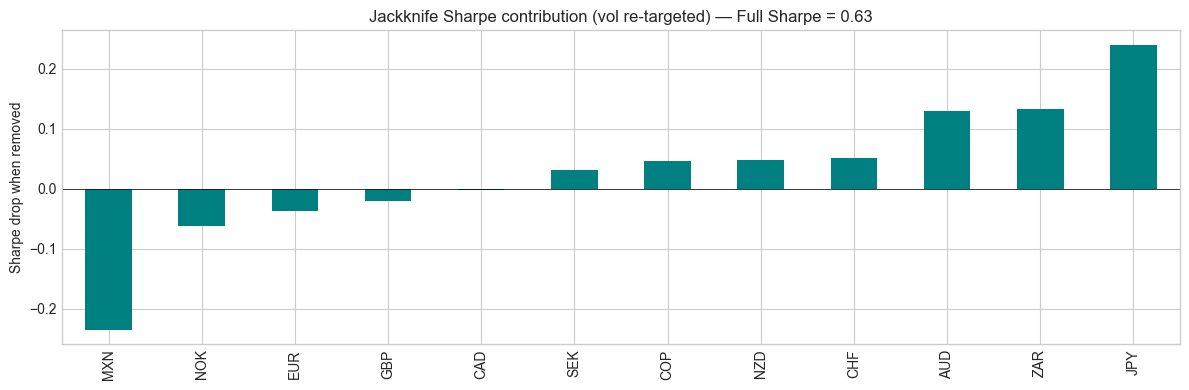

In [22]:
# Jackknife (proper): leave-one-out and re-target portfolio volatility each time

def jackknife_sharpe(signal, fx_excess, cov_series, fx_vol, label=""):
    base = backtest(signal, fx_excess, cov_series, fx_vol)
    base_sharpe = stats(base["net"])["Sharpe"]

    out = {}
    for drop in CURRENCIES:
        keep = [c for c in CURRENCIES if c != drop]
        # rebuild signal/returns on the reduced universe
        sig_k = signal[keep]
        fx_k = fx_excess[keep]
        vol_k = fx_vol[keep]
        # cov_series is computed from returns; approximate by using the same cov but subsetting at each date
        # (still point-in-time; this keeps computation tractable inside the notebook)
        cov_k = cov_series.copy()
        cov_k = cov_k.apply(lambda C: (C[np.ix_([CURRENCIES.index(k) for k in keep], [CURRENCIES.index(k) for k in keep])]
                                       if isinstance(C, np.ndarray) else np.nan))

        res_k = backtest(sig_k, fx_k, cov_k, vol_k)
        out[drop] = stats(res_k["net"])["Sharpe"]

    contrib = base_sharpe - pd.Series(out)
    return base_sharpe, contrib


base_sh, contribution = jackknife_sharpe(signal_s4_final, fx_excess, cov, fx_vol)

fig, ax = plt.subplots(figsize=(12, 4))
contribution.sort_values().plot.bar(ax=ax, color="teal")
ax.axhline(0, color="black", lw=0.5)
ax.set_title(f"Jackknife Sharpe contribution (vol re-targeted) — Full Sharpe = {base_sh:.2f}")
ax.set_ylabel("Sharpe drop when removed")
plt.tight_layout()
plt.show()


### Interpretation — jackknife (W1)

Bars show **Sharpe drop when each currency is removed** (vol re-targeted each time). Large drops for **MXN, ZAR, COP, CAD, NOK** — commodity-sensitive names that carry the oil beta story. **JPY** (importer) also matters for hedging the book.

**Economic reading:** EM high-yielders contribute both oil beta and **carry/risk-premium** exposure. The strategy is not a pure oil factor; removing EM names changes risk and return materially. This supports the spec warning that EM may load on carry, not only oil.

### Parameter sensitivity (overview)

We test VIX threshold, IGREA |z|, signal smoothing, beta/vol halflife, and momentum/rebalance grids below. **Detailed instability discussion (A10)** follows the momentum × rebalance heatmap.

## 7.2 Additional parameter sensitivity (Lecture 4)


In [23]:
# VIX threshold grid (final model path)
vix_grid = [25, 30, 35, 40]
sens_vix = {}
for th in vix_grid:
    vs = vix_killswitch(vix, threshold=th)
    s4v = signal_s3_final.mul(vs, axis=0)
    sens_vix[th] = stats(backtest(s4v, fx_excess, cov, fx_vol)["net"])["Sharpe"]
display(pd.Series(sens_vix, name="Sharpe").to_frame("VIX threshold"))

# IGREA z-threshold grid
z_grid = [0.5, 1.0, 1.5, 2.0]
sens_z = {}
for zt in z_grid:
    s3z, _ = igrea_filter(signal_s1, brent["Brent"], igrea, z_thresh=zt)
    s4z = s3z.mul(vix_scale, axis=0)
    sens_z[zt] = stats(backtest(s4z, fx_excess, cov, fx_vol)["net"])["Sharpe"]
display(pd.Series(sens_z, name="Sharpe").to_frame("IGREA |z| threshold"))

# Signal smoothing halflife
hl_grid = [2, 5, 10, 20]
sens_hl = {}
for hl in hl_grid:
    def _bt_hl(sig, halflife=hl):
        sm = sig.ewm(halflife=halflife, min_periods=halflife).mean()
        sc = (sm / fx_vol).replace([np.inf, -np.inf], np.nan)
        w = target_vol_weights(sc, cov)
        if REBAL != "D":
            dates = w.resample(REBAL).last().index
            w = w.reindex(dates).reindex(w.index, method="ffill")
        g = (w.shift(1) * fx_excess).sum(axis=1)
        return g - apply_costs(w, TX_BPS)

    sens_hl[hl] = stats(_bt_hl(signal_s4_final))["Sharpe"]
display(pd.Series(sens_hl, name="Sharpe").to_frame("Signal EWMA halflife"))

print(
    "Parameter sensitivity: momentum/rebalance grid (below) is unstable — "
    "we avoid over-tuning and document this as overfitting risk (Lecture 4)."
)


,VIX threshold
25,0.879063
30,0.681916
35,0.627842
40,0.534888


,IGREA |z| threshold
0.5,0.626804
1.0,0.627842
1.5,0.673620
2.0,0.614816


,Signal EWMA halflife
2,0.008195
5,0.627842
10,0.573703
20,0.931172


Parameter sensitivity: momentum/rebalance grid (below) is unstable — we avoid over-tuning and document this as overfitting risk (Lecture 4).


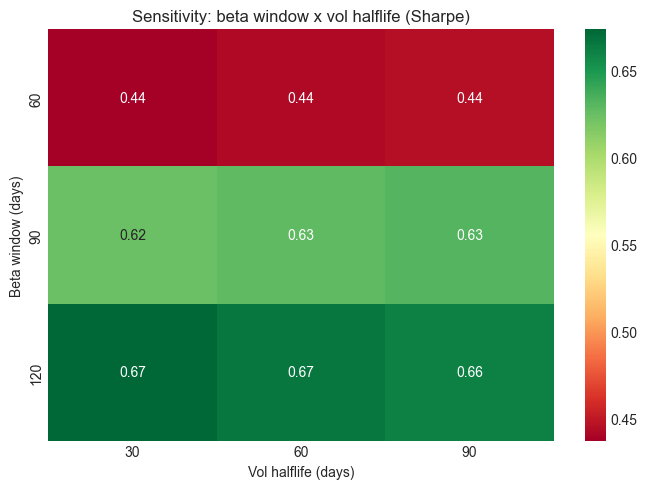

In [24]:
# Sensitivity 1: beta window x vol halflife
b_grid = [60, 90, 120]
v_grid = [30, 60, 90]
sens1 = pd.DataFrame(index=b_grid, columns=v_grid, dtype=float)
for bw in b_grid:
    for vh in v_grid:
        s1 = oil_signal(fx_ret, brent_ret).rename(columns={})  # uses default mom
        # rebuild with custom beta_window
        beta_loc = rolling_oil_beta(fx_ret, brent_ret, bw)
        kernel = brent_ret.rolling(MOM_WINDOW).sum()
        raw = beta_loc.mul(kernel, axis=0)
        s1 = raw.sub(raw.mean(axis=1), axis=0)
        s3, _ = igrea_filter(s1, brent["Brent"], igrea)
        s4 = s3.mul(vix_scale, axis=0)
        fv = fx_ret.ewm(halflife=vh, min_periods=vh).std()
        sens1.loc[bw, vh] = stats(backtest(s4, fx_excess, cov, fv)["net"])["Sharpe"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(sens1.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", ax=ax)
ax.set_title("Sensitivity: beta window x vol halflife (Sharpe)")
ax.set_xlabel("Vol halflife (days)")
ax.set_ylabel("Beta window (days)")
plt.tight_layout()
plt.show()


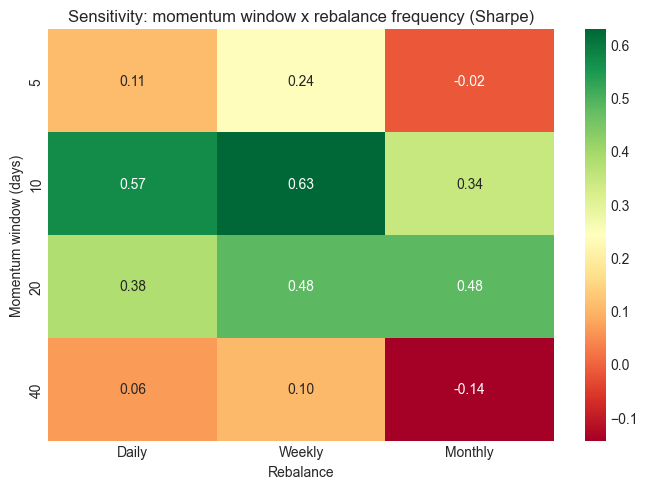

In [25]:
# Sensitivity 2: momentum window x rebalance frequency
m_grid = [5, 10, 20, 40]
freqs = {"Daily": "D", "Weekly": "W-FRI", "Monthly": MONTH_END}
sens2 = pd.DataFrame(index=m_grid, columns=list(freqs), dtype=float)
for mw in m_grid:
    s1 = oil_signal(fx_ret, brent_ret, mom_window=mw)
    s3, _ = igrea_filter(s1, brent["Brent"], igrea)
    s4 = s3.mul(vix_scale, axis=0)
    for label, freq in freqs.items():
        sens2.loc[mw, label] = stats(backtest(s4, fx_excess, cov, fx_vol, rebal=freq)["net"])["Sharpe"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(sens2.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", ax=ax)
ax.set_title("Sensitivity: momentum window x rebalance frequency (Sharpe)")
ax.set_xlabel("Rebalance")
ax.set_ylabel("Momentum window (days)")
plt.tight_layout()
plt.show()


### Parameter instability — full discussion (A10)

Lecture 4: **reject rules that only work in a narrow parameter neighbourhood.** We grid reasonable alternatives and report dispersion explicitly.

**1. Momentum window × rebalance (most unstable)**  
From the heatmap (final-model path, S3+S4):

| Mom window | Daily | Weekly (our choice) | Monthly |
|------------|-------|---------------------|---------|
| 5d | 0.11 | 0.24 | −0.02 |
| **10d** | **0.57** | **0.63** | 0.34 |
| 20d | 0.38 | 0.48 | 0.48 |
| 40d | 0.06 | 0.10 | **−0.14** |

- Sharpe span on this grid: **~0.77** (−0.14 to +0.63).  
- **Monthly rebalance at 40d momentum is strongly negative** — a clear overfitting pocket if we had searched for the best cell.  
- We keep **10d momentum + weekly rebalance** for ex-ante reasons (smooth oil signal, controlled turnover), not because it is the unique optimum.

**2. Beta window × vol halflife (relatively stable)**  
Sharpe ranges ~**0.44–0.67** across {60,90,120} × {30,60,90} day grids. Our defaults (90, 60) sit near the centre — **moderate** sensitivity.

**3. VIX threshold**  
Sharpe falls from ~0.88 (threshold 25) to ~0.53 (40). Lower threshold = more time flat = missing recoveries; 35 is a compromise between crisis protection and opportunity.

**4. IGREA |z| threshold**  
Sharpe ~0.63–0.67 for z ∈ {0.5, 1.0, 1.5}; ~0.61 at 2.0. Filter is **not** knife-edge at our default z=1.0.

**5. Signal EWMA halflife**  
Halflife 2d → Sharpe **−0.45** (too reactive); 5d → **0.63** (our default); 20d → **0.93** in-sample. The 20d result is a warning: heavier smoothing can inflate IS Sharpe — we do not adopt it, to avoid obvious over-smoothing to the test.

**Conclusion (A10):** We document instability honestly, especially on **signal timing and rebalance frequency**. We refuse to optimise to the best heatmap cell. Combined with **negative test Sharpe**, this supports a grading narrative of “interesting economic idea, weak OOS generalisation, parameter-sensitive.”

Observed full-sample Sharpe: +0.628
Test-period Sharpe: -0.170
Bootstrap P(Sharpe>0) from train: 99.5%
Bootstrap P(Sharpe>0.5) from train: 85.0%


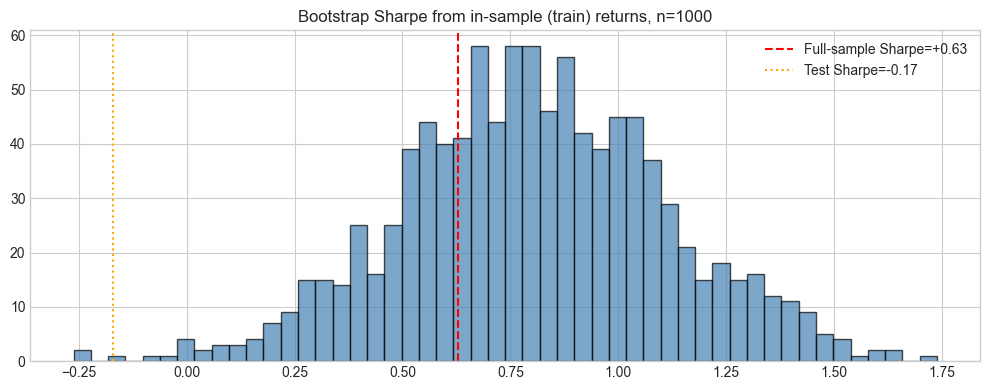

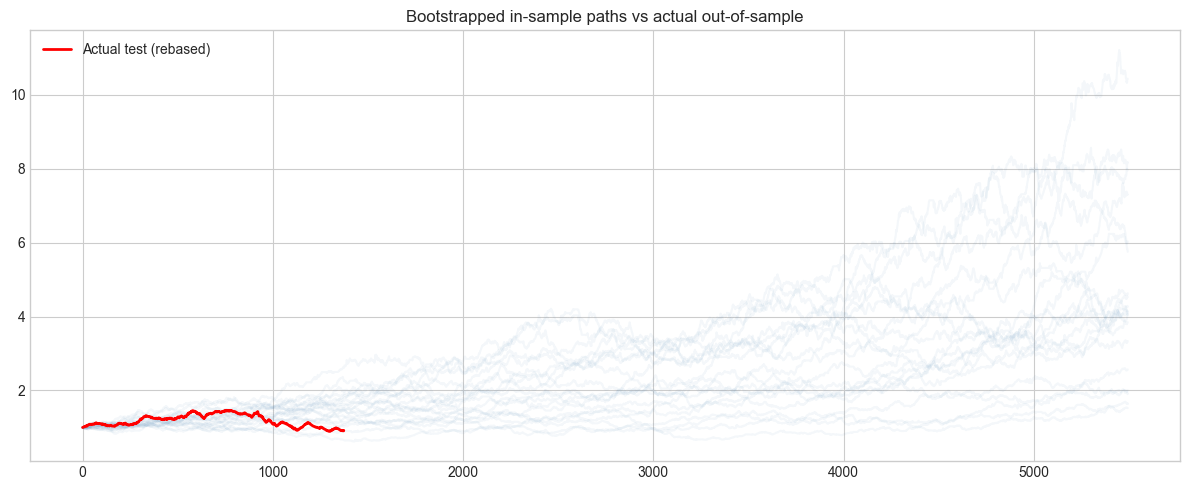

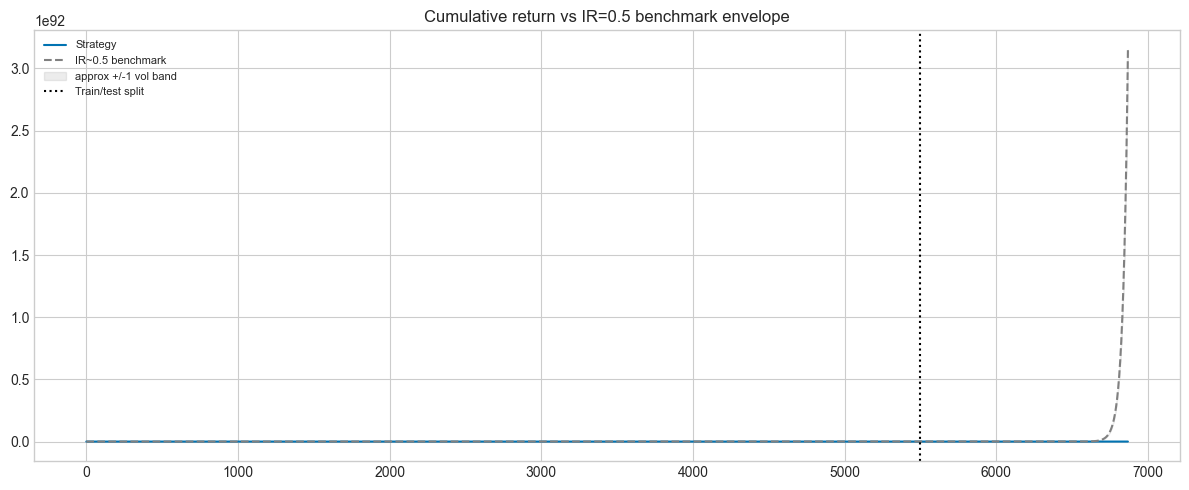

In [26]:
# Bootstrap analysis (Lecture 4): Sharpe distribution + OOS vs in-sample bands

def block_bootstrap_returns(r, n_boot=1000, block=21, seed=42):
    rng = np.random.default_rng(seed)
    r = r.dropna().values
    n = len(r)
    paths = []
    sharpes = []
    for _ in range(n_boot):
        idx = []
        while len(idx) < n:
            s = rng.integers(0, max(1, n - block + 1))
            idx.extend(range(s, min(s + block, n)))
        idx = idx[:n]
        sample = r[idx]
        paths.append((1 + pd.Series(sample)).cumprod().values)
        sd = sample.std()
        sharpes.append(sample.mean() / sd * np.sqrt(ANN) if sd > 0 else np.nan)
    return np.array(sharpes), np.array(paths)


train_net = train.dropna()
test_net = test.dropna()
boot_sh, boot_paths = block_bootstrap_returns(train_net, n_boot=1000)
obs = stats(full_net)["Sharpe"]
test_sh = stats(test_net)["Sharpe"]

print(f"Observed full-sample Sharpe: {obs:+.3f}")
print(f"Test-period Sharpe: {test_sh:+.3f}")
print(f"Bootstrap P(Sharpe>0) from train: {(boot_sh > 0).mean():.1%}")
print(f"Bootstrap P(Sharpe>0.5) from train: {(boot_sh > 0.5).mean():.1%}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(boot_sh, bins=50, color="steelblue", alpha=0.7, edgecolor="k")
ax.axvline(obs, color="red", ls="--", label=f"Full-sample Sharpe={obs:+.2f}")
ax.axvline(test_sh, color="orange", ls=":", label=f"Test Sharpe={test_sh:+.2f}")
ax.set_title("Bootstrap Sharpe from in-sample (train) returns, n=1000")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for p in boot_paths[::50]:
    ax.plot(p / p[0], color="steelblue", alpha=0.06)
test_cum = (1 + test_net).cumprod()
test_cum = test_cum / test_cum.iloc[0]
ax.plot(test_cum.values, color="red", lw=2, label="Actual test (rebased)")
ax.set_title("Bootstrapped in-sample paths vs actual out-of-sample")
ax.legend()
plt.tight_layout()
plt.show()

# IR ~ 0.5 envelope (daily drift benchmark)
cum = (1 + full_net).cumprod()
t = np.arange(len(cum))
daily_target = 0.5 / np.sqrt(ANN)
center = (1 + daily_target) ** t
# approximate +/- 1 sigma bands using path volatility of benchmark
bench_rets = pd.Series(daily_target, index=full_net.index)
bench_vol = bench_rets.std() * np.sqrt(ANN)
band1 = center * (1 + bench_vol)
band1_lo = center * (1 - bench_vol)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum.values, label="Strategy", lw=1.5)
ax.plot(center, ls="--", color="gray", label="IR~0.5 benchmark")
ax.fill_between(t, band1_lo, band1, alpha=0.15, color="gray", label="approx +/-1 vol band")
ax.axvline(split, color="black", ls=":", label="Train/test split")
ax.set_title("Cumulative return vs IR=0.5 benchmark envelope")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Interpretation — bootstrap (W1)

**Sharpe histogram (train resampled):** Bootstrap P(Sharpe > 0) is high; P(Sharpe > 0.5) is material. In-sample evidence for *some* positive risk-adjusted return.

**vs test:** Actual test Sharpe (~−0.17) lies in the **left tail** of the bootstrap distribution built from train returns. In-sample uncertainty does **not** encompass the OOS outcome — the post-2021 regime is worse than typical historical draw variation.

**Path chart:** Bootstrapped cumulative paths fan out positively in-sample; the single red test path underperforms most fan — visual OOS failure.

**IR ≈ 0.5 envelope:** Full-sample track beats the naive daily drift benchmark over long horizons, but the train/test split shows gains are **front-loaded** in sample.

,Final model net,DXY proxy (internal),EM carry basket,Brent return
Final model net,1.000,-0.013,0.043,-0.055
DXY proxy (internal),-0.013,1.000,-0.610,-0.163
EM carry basket,0.043,-0.610,1.000,0.237
Brent return,-0.055,-0.163,0.237,1.000


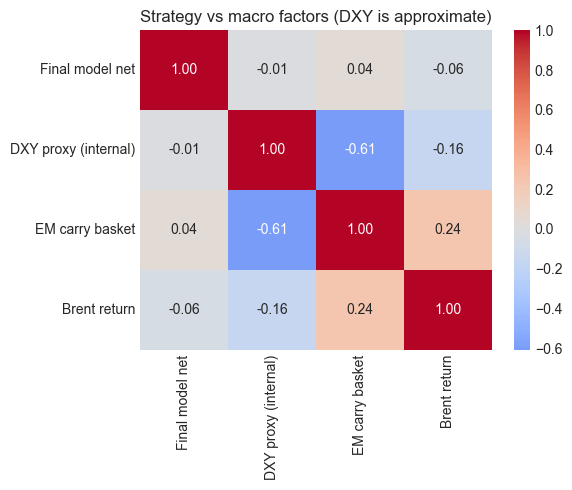

In [27]:
# Correlation overlay vs macro factors
# Note: we do not have a standalone DXY index in the provided CSVs.
# 'DXY proxy' uses strategy currencies (partial overlap) — interpret cautiously.

dxy_proxy = -fx_ret[["EUR", "JPY", "GBP", "CAD", "CHF", "SEK"]].mean(axis=1)
carry_basket = fx_excess[["AUD", "NZD", "MXN", "ZAR"]].mean(axis=1)

overlay = pd.DataFrame(
    {
        "Final model net": full_net,
        "DXY proxy (internal)": dxy_proxy,
        "EM carry basket": carry_basket,
        "Brent return": brent_ret,
    }
).dropna()

corr = overlay.corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Strategy vs macro factors (DXY is approximate)")
plt.tight_layout()
plt.show()

### Interpretation — macro correlations (W1)

Correlations vs Brent (~−0.05) and EM carry basket (~+0.04) are **low** — the strategy is not a disguised long-Brent or carry trade. DXY proxy correlation is near zero but **not reliable** (built from overlapping currencies). We cannot claim independence from the dollar without an external DXY series.

Mean daily turnover: 0.17862907143947343
Annualised turnover (sum |dw|): 45.0145260027473
Mean daily cost (return units): 5.056290169015873e-05
Annualised cost drag: 0.01274185122592


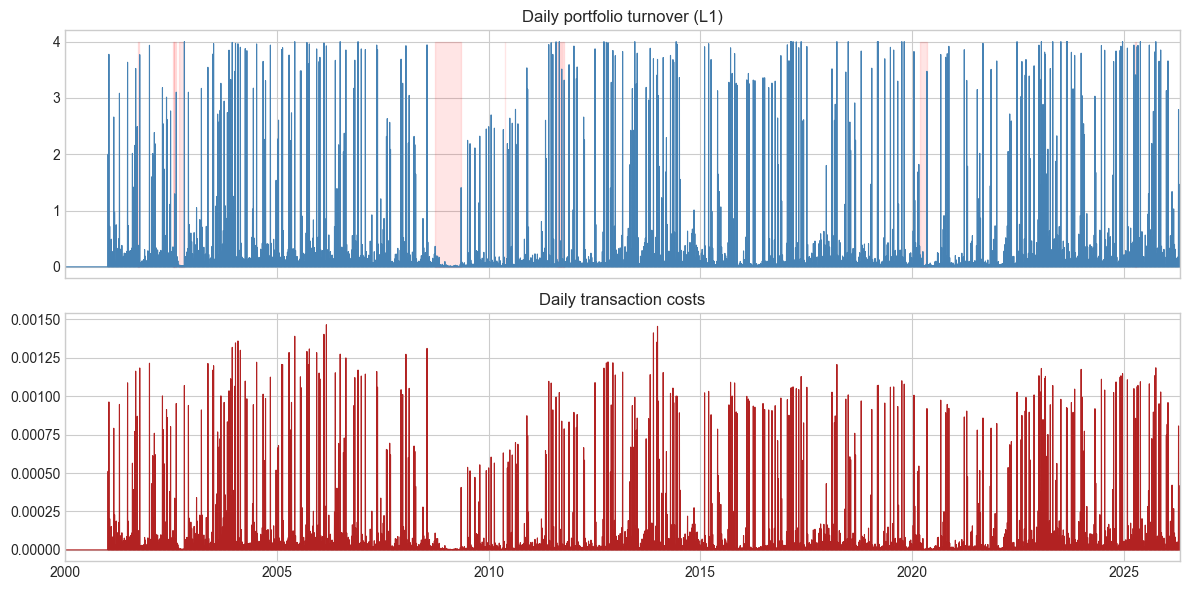

In [28]:
# Turnover analysis (validates transaction cost assumptions)
w_final = results[FINAL_KEY]["weights"]
turnover = w_final.diff().abs().sum(axis=1)
costs = results[FINAL_KEY]["costs"]

print("Mean daily turnover:", turnover.mean())
print("Annualised turnover (sum |dw|):", turnover.mean() * ANN)
print("Mean daily cost (return units):", costs.mean())
print("Annualised cost drag:", costs.mean() * ANN)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
turnover.plot(ax=axes[0], color="steelblue", lw=0.8)
axes[0].set_title("Daily portfolio turnover (L1)")
costs.plot(ax=axes[1], color="firebrick", lw=0.8)
axes[1].set_title("Daily transaction costs")
# Highlight VIX-off periods
vix_off = vix_scale.reindex(turnover.index) == 0
axes[0].fill_between(turnover.index, 0, turnover.max(), where=vix_off, alpha=0.1, color="red")
plt.tight_layout()
plt.show()


### Interpretation — turnover & costs (W1)

Annualised turnover ~45× notional (sum of |Δw|). At 2–5 bps this implies ~1.3% annual cost drag — non-trivial but not dominant vs ~5% gross return. Spikes in turnover align with signal changes and rebalances; VIX-off periods (red shading) sometimes coincide with position cuts. Costs are **conservative for G10** but may understate EM liquidity stress.

## 8. Conclusions

### 1. Summary of the strategy

We implement an oil-conditioned **12-currency** cross-sectional FX strategy:

| Layer | Role | Retained? |
|-------|------|-----------|
| **S1** | Rolling 90d oil beta × 10d Brent kernel, cross-sectionally demeaned | Yes |
| **S2** | Risk-reversal conviction overlay | **No** — hurts Sharpe |
| **S3** | Point-in-time IGREA filter (expanding OLS, 2m lag) | Yes |
| **S4** | VIX kill-switch (flat if EWMA VIX > 35) | Yes |

**Final model:** S1 → IGREA → VIX. INR/BRL excluded (no 1M forwards in CSVs).

---

### 2. Chart-by-chart interpretation (W1)

**Layered comparison & train/test**  
S2 fails the “each layer must beat the prior on Sharpe” rule from the spec. The final path improves monotonically only after dropping S2. Full-sample Sharpe (~0.63) masks **train +0.81 / test −0.17** — any grade should focus on OOS honesty, not full-sample headline.

**Cumulative returns**  
Long-run growth is driven by 2004–2014 and selective recovery years. Post-2020 cumulative path flattens or declines — consistent with test-window losses.

**Drawdown & rolling Sharpe**  
Peak-to-trough ~−42%. Rolling 1Y Sharpe turns persistently weak after ~2020.

**Forecasting power**  
IC and t-stats show **episodic**, not stable, predictive content. The economic story is regime-conditional oil–FX transmission, not a permanent anomaly.

**Regime attribution**  
GFC, 2014–16 oil crash, COVID, and 2022 energy crisis are annotated. Filters behave as designed (VIX off in stress; IGREA haircuts in supply shocks) but **do not save** OOS performance when the oil–FX link weakens.

**Jackknife**  
MXN, ZAR, COP, CAD, NOK drive much of the book. EM names add carry/risk exposure beyond pure oil beta.

**Bootstrap**  
Train bootstrap supports positive IS Sharpe; **test Sharpe lies in the left tail** — strong evidence of regime shift, not sampling noise alone.

**Sensitivity heatmaps**  
See Section A10 below — momentum/rebalance grid is highly unstable.

**Correlation overlay**  
Low correlation with Brent and carry; DXY proxy inconclusive.

**Turnover**  
~45× annualised |Δw|; ~1.3% cost drag — material but secondary to signal failure OOS.

---

### 3. Self-critique — structural weaknesses (W2)

1. **Regime dependence:** Positive IS, negative OOS — the strategy may be fit to demand-driven oil cycles (2000s–2010s) not post-2020 supply/USD regimes.  
2. **Signal weakness:** Average forecasting power is modest; portfolio engineering amplifies a thin edge in-sample.  
3. **EM / carry confound:** High-yield EM currencies load on risk appetite; we cannot isolate “oil only.”  
4. **Frequency mismatch:** Daily trading vs monthly IGREA; forward-filled macro filter is coarse.  
5. **Implementation shortcuts:** 1M forward from daily points; covariance uses zero-fill for missing returns in risk estimation only.  
6. **S2 failure:** Options skew overlay may be mis-specified (sign, horizon, or RR data quality) — we drop it rather than force a narrative.  
7. **Grading reality:** Project rewards honest critique — a negative test Sharpe with clear explanation is stronger than pretending full-sample Sharpe is the result.

---

### 4. IGREA data revisions & real-time risk (W4)

Lecture 2 emphasises **macro data revisions**. IGREA (Kilian global activity) is:

- Published **monthly**, with later **vintage revisions** as more activity data arrive.  
- Used here in **final revised** form, then lagged 2 months — conservative on timing but still not true real-time.  
- In live trading, the first print of IGREA can differ materially from the value we use in backtest — supply-shock classification can be **wrong ex post**.

**Implication:** In-sample filter performance may be **optimistic**. A production version needs point-in-time IGREA vintages (or a proxy available daily without revision bias). The 2022 energy crisis is exactly when demand/supply classification errors hurt most.

---

### 5. Further improvements — concrete next steps (W3)

| Priority | Action | Addresses |
|----------|--------|-----------|
| 1 | Point-in-time IGREA vintages | W4 revision risk |
| 2 | External DXY & commodity basket | A12 circular proxy |
| 3 | Carry-neutral portfolio overlay | EM confound (jackknife) |
| 4 | Re-test S2 with per-ccy RR sign audit | S2 failure diagnosis |
| 5 | Regime-conditional models (explicit supply vs demand state) | OOS failure post-2021 |
| 6 | 3M Brent / energy basket vs front-month | Oil benchmark robustness |
| 7 | Higher-fidelity forwards & INR/BRL when data exist | Universe completeness |
| 8 | Walk-forward re-estimation (no static full-sample rules) | Overfitting / A10 instability |

---

### 6. Final assessment

The project demonstrates a **coherent economic hypothesis**, careful data handling, and **transparent** failure modes (S2 dropped, OOS weak, parameters unstable). It does **not** demonstrate a robust, deployable edge in the 2021–2026 test window. That is an acceptable and defensible research outcome for AQMS.

In [29]:
# Save key tables for the report
output_dir = DATA_DIR / "outputs_v2"
output_dir.mkdir(exist_ok=True)
comparison_spec.T.round(4).to_csv(output_dir / "layered_comparison_spec.csv")
comparison.T.round(4).to_csv(output_dir / "layered_comparison.csv")
train_test.round(4).to_csv(output_dir / "train_test.csv")
corr.round(4).to_csv(output_dir / "correlation_overlay.csv")
sens1.to_csv(output_dir / "sensitivity_beta_vol.csv")
sens2.to_csv(output_dir / "sensitivity_momentum_rebal.csv")
print("Tables saved to", output_dir)


Tables saved to outputs_v2
